# Import Necessary Libraries

In [1058]:
import pandas as pd
import numpy as np
from pandas.tseries.offsets import MonthBegin
import matplotlib.pyplot as plt
import seaborn as sns
from pmdarima import auto_arima
from statsmodels.tsa.stattools import adfuller
from numpy import log
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy.stats.mstats import mquantiles
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

# Import Dataset

In [1059]:
# Load the dataset 
data = pd.read_csv('https://raw.githubusercontent.com/selvinfurtado01/schulich_predictive_modeling/refs/heads/main/data_set_hackathon.csv')
data.head()

,order_date,requested_delivery_date,Customer Country Code,Product Code,Description,order_type,Customer Order Code,value,Curr,items,Route
0,13.07.2009,28.01.2010,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435553,2337.00,RUB,6,RU0001
1,15.07.2009,24.03.2010,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435694,10160.25,RUB,23,RU0001
2,16.07.2009,04.02.2010,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435741,2992.50,RUB,7,RU0001
3,17.07.2009,04.02.2010,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435907,4061.25,RUB,9,RU0001
4,21.07.2009,01.02.2010,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435963,2208.75,RUB,5,RU0001


In [1060]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2420 entries, 0 to 2419
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   order_date               2420 non-null   object 
 1   requested_delivery_date  2420 non-null   object 
 2   Customer Country Code    2420 non-null   object 
 3   Product Code             2420 non-null   object 
 4   Description              2420 non-null   object 
 5   order_type               2420 non-null   object 
 6   Customer Order Code      2420 non-null   int64  
 7   value                    2420 non-null   float64
 8   Curr                     2420 non-null   object 
 9   items                    2420 non-null   object 
 10  Route                    2420 non-null   object 
dtypes: float64(1), int64(1), object(9)
memory usage: 208.1+ KB


# Data Cleaning + EDA

In [1061]:
data['items'].value_counts()

items
\N     346
4      295
6      262
5      255
3      214
7      209
8      194
1      157
10     104
2       58
12      44
9       40
11      36
14      31
15      24
13      21
16      18
18      12
20      12
22       8
30       7
36       7
24       6
26       6
42       5
21       5
17       4
19       3
65       3
25       3
50       3
23       2
60       2
49       2
31       1
63       1
385      1
70       1
45       1
100      1
64       1
370      1
241      1
200      1
33       1
54       1
73       1
220      1
190      1
300      1
35       1
39       1
32       1
27       1
410      1
55       1
Name: count, dtype: int64

In [1062]:
# Step 1: Normalize column names
data.columns = data.columns.str.strip().str.replace(' ', '_').str.lower()

# Step 2: Convert dates to datetime
data['order_date'] = pd.to_datetime(data['order_date'], format='%d.%m.%Y', errors='coerce')
data['requested_delivery_date'] = pd.to_datetime(data['requested_delivery_date'], format='%d.%m.%Y', errors='coerce')

# Step 3: Clean and convert 'items' column
data['items'] = data['items'].replace(r'\\N', 0, regex=True)  # Replace '\N' with 0
data['items'] = data['items'].astype('int64')

# Step 4: Remove rows with negative values in numeric columns
numeric_cols = data.select_dtypes(include=['number']).columns
data = data[(data[numeric_cols] >= 0).all(axis=1)]

# Step 5: Handle missing values (if any remain)
data = data.dropna()  # Drop rows with any remaining missing values

In [1063]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2419 entries, 0 to 2419
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   order_date               2419 non-null   datetime64[ns]
 1   requested_delivery_date  2419 non-null   datetime64[ns]
 2   customer_country_code    2419 non-null   object        
 3   product_code             2419 non-null   object        
 4   description              2419 non-null   object        
 5   order_type               2419 non-null   object        
 6   customer_order_code      2419 non-null   int64         
 7   value                    2419 non-null   float64       
 8   curr                     2419 non-null   object        
 9   items                    2419 non-null   int64         
 10  route                    2419 non-null   object        
dtypes: datetime64[ns](2), float64(1), int64(2), object(6)
memory usage: 226.8+ KB


In [1064]:
data['items'].value_counts()

items
0      345
4      295
6      262
5      255
3      214
7      209
8      194
1      157
10     104
2       58
12      44
9       40
11      36
14      31
15      24
13      21
16      18
18      12
20      12
22       8
30       7
36       7
24       6
26       6
42       5
21       5
17       4
19       3
65       3
25       3
50       3
23       2
60       2
49       2
31       1
63       1
385      1
70       1
45       1
100      1
64       1
370      1
241      1
200      1
33       1
54       1
73       1
220      1
190      1
300      1
35       1
39       1
32       1
27       1
410      1
55       1
Name: count, dtype: int64

In [1065]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2419 entries, 0 to 2419
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   order_date               2419 non-null   datetime64[ns]
 1   requested_delivery_date  2419 non-null   datetime64[ns]
 2   customer_country_code    2419 non-null   object        
 3   product_code             2419 non-null   object        
 4   description              2419 non-null   object        
 5   order_type               2419 non-null   object        
 6   customer_order_code      2419 non-null   int64         
 7   value                    2419 non-null   float64       
 8   curr                     2419 non-null   object        
 9   items                    2419 non-null   int64         
 10  route                    2419 non-null   object        
dtypes: datetime64[ns](2), float64(1), int64(2), object(6)
memory usage: 226.8+ KB


In [1066]:
data.rename(columns={'order_date': 'Order Date', 'requested_delivery_date': 'Requested Delivery Date', 'order_type': 'Order Type', 
                     'value': 'Value', 'curr': 'Currency', 'items': 'Items', 'route':'Route', 'customer_country_code': 'Customer Country Code',
                     'product_code': 'Product Code', 'description': 'Description', 'customer_order_code':'Customer Order Code'}, inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2419 entries, 0 to 2419
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Order Date               2419 non-null   datetime64[ns]
 1   Requested Delivery Date  2419 non-null   datetime64[ns]
 2   Customer Country Code    2419 non-null   object        
 3   Product Code             2419 non-null   object        
 4   Description              2419 non-null   object        
 5   Order Type               2419 non-null   object        
 6   Customer Order Code      2419 non-null   int64         
 7   Value                    2419 non-null   float64       
 8   Currency                 2419 non-null   object        
 9   Items                    2419 non-null   int64         
 10  Route                    2419 non-null   object        
dtypes: datetime64[ns](2), float64(1), int64(2), object(6)
memory usage: 226.8+ KB


In [1067]:
data.isna().any()

Order Date                 False
Requested Delivery Date    False
Customer Country Code      False
Product Code               False
Description                False
Order Type                 False
Customer Order Code        False
Value                      False
Currency                   False
Items                      False
Route                      False
dtype: bool

In [1068]:
data.isnull().sum()

Order Date                 0
Requested Delivery Date    0
Customer Country Code      0
Product Code               0
Description                0
Order Type                 0
Customer Order Code        0
Value                      0
Currency                   0
Items                      0
Route                      0
dtype: int64

In [1069]:
data.isna().sum()

Order Date                 0
Requested Delivery Date    0
Customer Country Code      0
Product Code               0
Description                0
Order Type                 0
Customer Order Code        0
Value                      0
Currency                   0
Items                      0
Route                      0
dtype: int64

In [1070]:
data.dtypes

Order Date                 datetime64[ns]
Requested Delivery Date    datetime64[ns]
Customer Country Code              object
Product Code                       object
Description                        object
Order Type                         object
Customer Order Code                 int64
Value                             float64
Currency                           object
Items                               int64
Route                              object
dtype: object

In [1071]:
# Calculate Lead Time in days
data['Lead Time'] = (data['Requested Delivery Date'] - data['Order Date']).dt.days

In [1072]:
data.isna().sum()

Order Date                 0
Requested Delivery Date    0
Customer Country Code      0
Product Code               0
Description                0
Order Type                 0
Customer Order Code        0
Value                      0
Currency                   0
Items                      0
Route                      0
Lead Time                  0
dtype: int64

In [1073]:
data.describe()

,Order Date,Requested Delivery Date,Customer Order Code,Value,Items,Lead Time
count,2419,2419,2.419000e+03,2419.000000,2419.000000,2419.000000
mean,2011-03-21 15:59:00.471269120,2011-10-28 21:53:12.228193536,3.200672e+09,1163.457404,7.106656,221.245969
min,2009-07-08 00:00:00,2010-01-28 00:00:00,3.200435e+09,0.000000,0.000000,-3.000000
25%,2011-01-07 00:00:00,2011-09-01 00:00:00,3.200614e+09,33.030000,3.000000,196.000000
50%,2011-07-13 00:00:00,2012-02-15 00:00:00,3.200711e+09,70.490000,5.000000,217.000000
75%,2011-08-03 12:00:00,2012-03-20 00:00:00,3.200729e+09,1363.200000,8.000000,251.000000
max,2012-11-19 00:00:00,2013-04-15 00:00:00,3.201062e+09,38937.500000,410.000000,459.000000
std,NaN,NaN,1.004585e+05,2561.015296,18.412228,53.254864


In [1074]:
# Define Seasons
def month_to_season(month):
    if month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Fall'
    else:
        return 'Winter'

data['Order Day'] = data['Order Date'].dt.day
data['Order Month'] = data['Order Date'].dt.month
data['Order Year'] = data['Order Date'].dt.year

data['O_Season'] = data['Order Month'].apply(month_to_season)
data['O_Season_Num'] = data['O_Season'].map({'Winter': 1, 'Spring': 2, 'Summer': 3, 'Fall': 4})

In [1075]:
data.head()

,Order Date,Requested Delivery Date,Customer Country Code,Product Code,Description,Order Type,Customer Order Code,Value,Currency,Items,Route,Lead Time,Order Day,Order Month,Order Year,O_Season,O_Season_Num
0,2009-07-13,2010-01-28,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435553,2337.00,RUB,6,RU0001,199,13,7,2009,Summer,3
1,2009-07-15,2010-03-24,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435694,10160.25,RUB,23,RU0001,252,15,7,2009,Summer,3
2,2009-07-16,2010-02-04,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435741,2992.50,RUB,7,RU0001,203,16,7,2009,Summer,3
3,2009-07-17,2010-02-04,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435907,4061.25,RUB,9,RU0001,202,17,7,2009,Summer,3
4,2009-07-21,2010-02-01,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435963,2208.75,RUB,5,RU0001,195,21,7,2009,Summer,3


In [1076]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2419 entries, 0 to 2419
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Order Date               2419 non-null   datetime64[ns]
 1   Requested Delivery Date  2419 non-null   datetime64[ns]
 2   Customer Country Code    2419 non-null   object        
 3   Product Code             2419 non-null   object        
 4   Description              2419 non-null   object        
 5   Order Type               2419 non-null   object        
 6   Customer Order Code      2419 non-null   int64         
 7   Value                    2419 non-null   float64       
 8   Currency                 2419 non-null   object        
 9   Items                    2419 non-null   int64         
 10  Route                    2419 non-null   object        
 11  Lead Time                2419 non-null   int64         
 12  Order Day                2419 non-null 

In [1077]:
#data['Order Day'] = data['Order Day'].fillna(0).astype('int64')

#data['Order Month'] = data['Order Month'].fillna(0).astype('int64')
#data['Order Year'] = data['Order Year'].fillna(0).astype('int64')

In [1078]:
data.head(10)

,Order Date,Requested Delivery Date,Customer Country Code,Product Code,Description,Order Type,Customer Order Code,Value,Currency,Items,Route,Lead Time,Order Day,Order Month,Order Year,O_Season,O_Season_Num
0,2009-07-13,2010-01-28,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435553,2337.00,RUB,6,RU0001,199,13,7,2009,Summer,3
1,2009-07-15,2010-03-24,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435694,10160.25,RUB,23,RU0001,252,15,7,2009,Summer,3
2,2009-07-16,2010-02-04,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435741,2992.50,RUB,7,RU0001,203,16,7,2009,Summer,3
3,2009-07-17,2010-02-04,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435907,4061.25,RUB,9,RU0001,202,17,7,2009,Summer,3
4,2009-07-21,2010-02-01,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435963,2208.75,RUB,5,RU0001,195,21,7,2009,Summer,3
5,2009-07-20,2010-02-01,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435982,2173.12,RUB,5,RU0001,196,20,7,2009,Summer,3
6,2009-07-20,2010-01-28,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200436075,3344.00,RUB,8,RU0001,192,20,7,2009,Summer,3
7,2009-07-20,2010-02-01,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200436082,3158.75,RUB,7,RU0001,196,20,7,2009,Summer,3
8,2009-07-21,2010-02-04,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200436158,7068.00,RUB,16,RU0001,198,21,7,2009,Summer,3
9,2009-07-21,2010-02-01,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200436332,2550.75,RUB,6,RU0001,195,21,7,2009,Summer,3


In [1079]:
data.isna().sum()

Order Date                 0
Requested Delivery Date    0
Customer Country Code      0
Product Code               0
Description                0
Order Type                 0
Customer Order Code        0
Value                      0
Currency                   0
Items                      0
Route                      0
Lead Time                  0
Order Day                  0
Order Month                0
Order Year                 0
O_Season                   0
O_Season_Num               0
dtype: int64

In [1080]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2419 entries, 0 to 2419
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Order Date               2419 non-null   datetime64[ns]
 1   Requested Delivery Date  2419 non-null   datetime64[ns]
 2   Customer Country Code    2419 non-null   object        
 3   Product Code             2419 non-null   object        
 4   Description              2419 non-null   object        
 5   Order Type               2419 non-null   object        
 6   Customer Order Code      2419 non-null   int64         
 7   Value                    2419 non-null   float64       
 8   Currency                 2419 non-null   object        
 9   Items                    2419 non-null   int64         
 10  Route                    2419 non-null   object        
 11  Lead Time                2419 non-null   int64         
 12  Order Day                2419 non-null 

In [1081]:
data.head(10)

,Order Date,Requested Delivery Date,Customer Country Code,Product Code,Description,Order Type,Customer Order Code,Value,Currency,Items,Route,Lead Time,Order Day,Order Month,Order Year,O_Season,O_Season_Num
0,2009-07-13,2010-01-28,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435553,2337.00,RUB,6,RU0001,199,13,7,2009,Summer,3
1,2009-07-15,2010-03-24,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435694,10160.25,RUB,23,RU0001,252,15,7,2009,Summer,3
2,2009-07-16,2010-02-04,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435741,2992.50,RUB,7,RU0001,203,16,7,2009,Summer,3
3,2009-07-17,2010-02-04,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435907,4061.25,RUB,9,RU0001,202,17,7,2009,Summer,3
4,2009-07-21,2010-02-01,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435963,2208.75,RUB,5,RU0001,195,21,7,2009,Summer,3
5,2009-07-20,2010-02-01,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435982,2173.12,RUB,5,RU0001,196,20,7,2009,Summer,3
6,2009-07-20,2010-01-28,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200436075,3344.00,RUB,8,RU0001,192,20,7,2009,Summer,3
7,2009-07-20,2010-02-01,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200436082,3158.75,RUB,7,RU0001,196,20,7,2009,Summer,3
8,2009-07-21,2010-02-04,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200436158,7068.00,RUB,16,RU0001,198,21,7,2009,Summer,3
9,2009-07-21,2010-02-01,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200436332,2550.75,RUB,6,RU0001,195,21,7,2009,Summer,3


In [1082]:
data_temp = data.copy()

In [1083]:
data_temp['Year-Season'] = data_temp['Order Year'].astype(str) + '-' + data_temp['O_Season_Num'].astype(str)
data_temp.head()

,Order Date,Requested Delivery Date,Customer Country Code,Product Code,Description,Order Type,Customer Order Code,Value,Currency,Items,Route,Lead Time,Order Day,Order Month,Order Year,O_Season,O_Season_Num,Year-Season
0,2009-07-13,2010-01-28,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435553,2337.00,RUB,6,RU0001,199,13,7,2009,Summer,3,2009-3
1,2009-07-15,2010-03-24,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435694,10160.25,RUB,23,RU0001,252,15,7,2009,Summer,3,2009-3
2,2009-07-16,2010-02-04,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435741,2992.50,RUB,7,RU0001,203,16,7,2009,Summer,3,2009-3
3,2009-07-17,2010-02-04,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435907,4061.25,RUB,9,RU0001,202,17,7,2009,Summer,3,2009-3
4,2009-07-21,2010-02-01,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435963,2208.75,RUB,5,RU0001,195,21,7,2009,Summer,3,2009-3


In [1084]:
seasonal_orders = data_temp.groupby('Year-Season')['Customer Order Code'].nunique().reset_index()
data_temp['Year-Season'] = data_temp['Order Year'].astype(str) + '-' + data_temp['O_Season_Num'].astype(str)
seasonal_orders.head()

,Year-Season,Customer Order Code
0,2009-1,21
1,2009-3,47
2,2009-4,18
3,2010-1,99
4,2010-2,55


In [1085]:
print(seasonal_orders.columns)

Index(['Year-Season', 'Customer Order Code'], dtype='object')


In [1086]:
seasonal_orders.set_index('Year-Season', inplace=True)
seasonal_orders.head()

,Customer Order Code
Year-Season,
2009-1,21
2009-3,47
2009-4,18
2010-1,99
2010-2,55


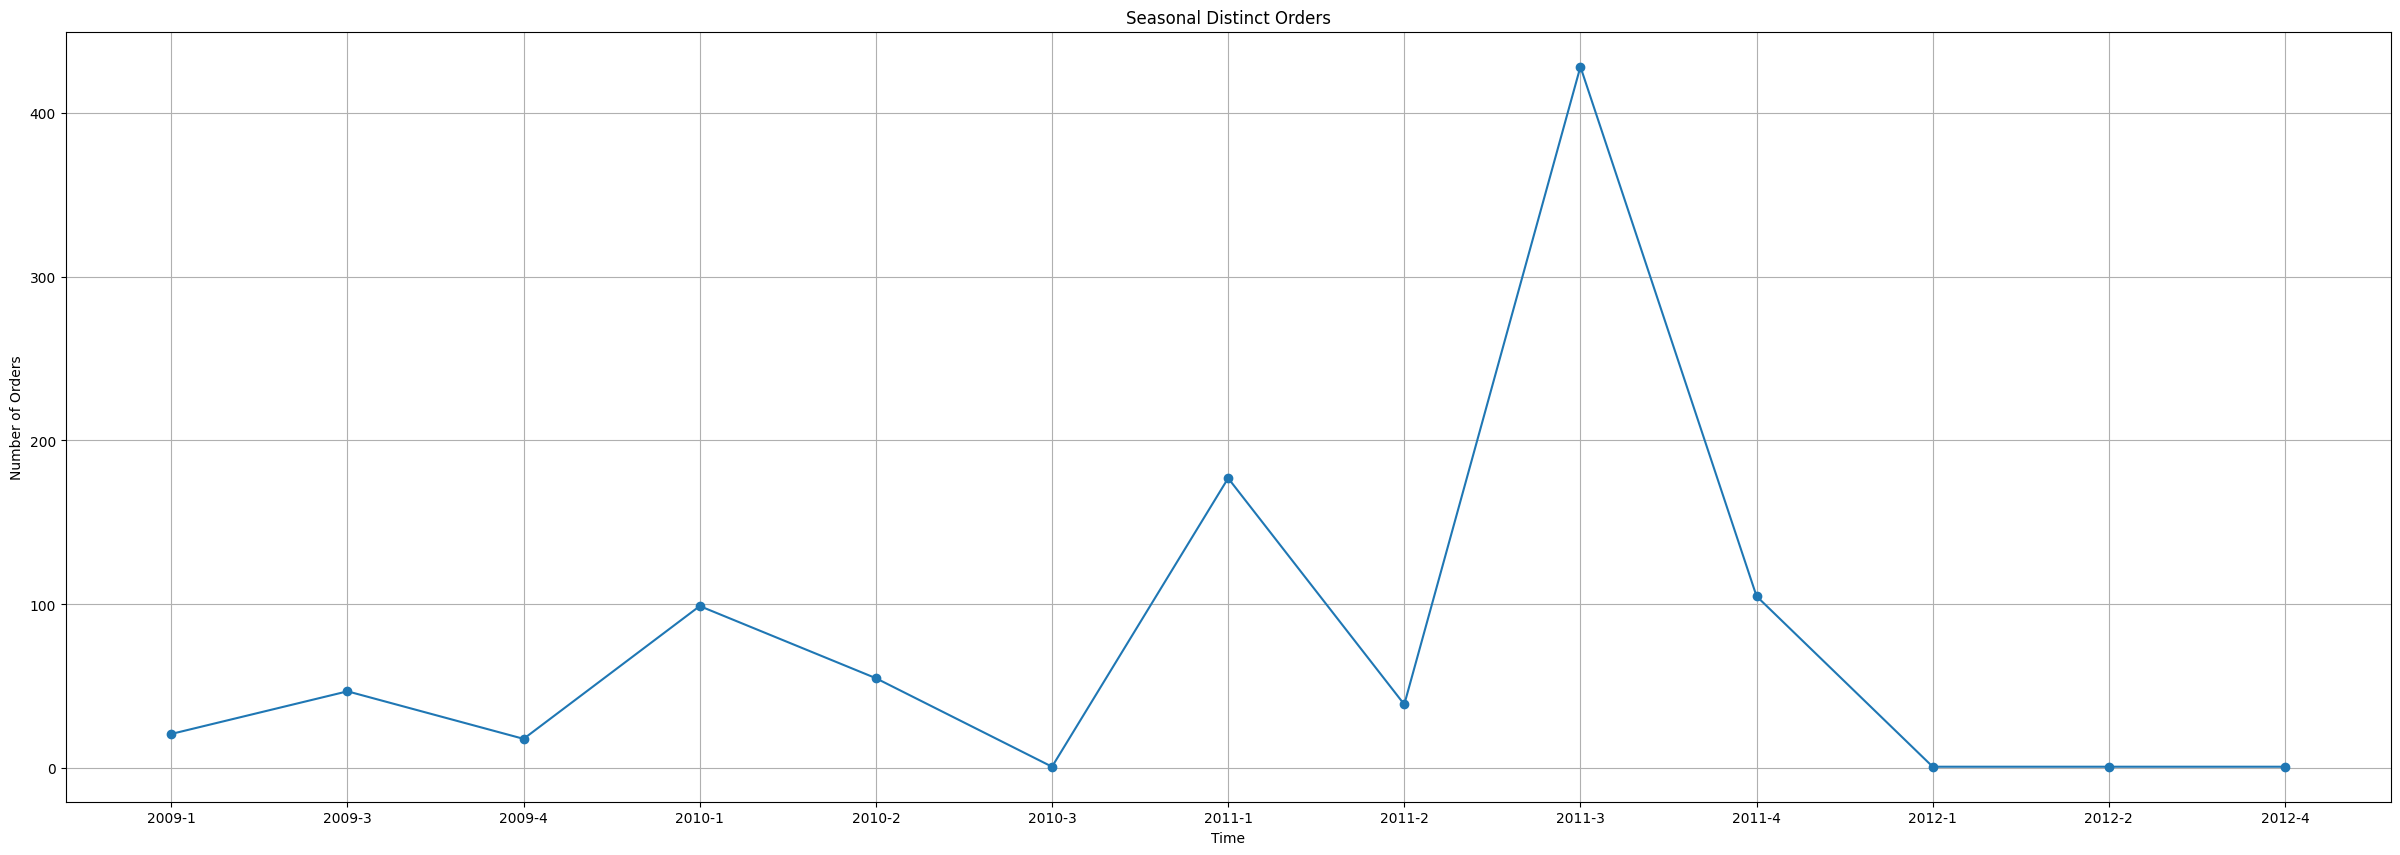

In [1087]:
# Visualize the seasonal distinct orders
plt.figure(figsize=(30, 10))
plt.plot(seasonal_orders['Customer Order Code'], marker='o', linestyle='-')
plt.title('Seasonal Distinct Orders')
plt.xlabel('Time')
plt.ylabel('Number of Orders')
plt.grid()
plt.show()

# Monthly Distinct Orders

In [1088]:
data.head()

,Order Date,Requested Delivery Date,Customer Country Code,Product Code,Description,Order Type,Customer Order Code,Value,Currency,Items,Route,Lead Time,Order Day,Order Month,Order Year,O_Season,O_Season_Num
0,2009-07-13,2010-01-28,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435553,2337.00,RUB,6,RU0001,199,13,7,2009,Summer,3
1,2009-07-15,2010-03-24,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435694,10160.25,RUB,23,RU0001,252,15,7,2009,Summer,3
2,2009-07-16,2010-02-04,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435741,2992.50,RUB,7,RU0001,203,16,7,2009,Summer,3
3,2009-07-17,2010-02-04,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435907,4061.25,RUB,9,RU0001,202,17,7,2009,Summer,3
4,2009-07-21,2010-02-01,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435963,2208.75,RUB,5,RU0001,195,21,7,2009,Summer,3


In [1089]:
data3 = data.copy()

In [1090]:
data3.isna().sum()

Order Date                 0
Requested Delivery Date    0
Customer Country Code      0
Product Code               0
Description                0
Order Type                 0
Customer Order Code        0
Value                      0
Currency                   0
Items                      0
Route                      0
Lead Time                  0
Order Day                  0
Order Month                0
Order Year                 0
O_Season                   0
O_Season_Num               0
dtype: int64

In [1091]:
# Extract the month and year from the 'Order Date'
data3['Year-Month'] = data3['Order Date'].dt.to_period('M')
data3.head()

,Order Date,Requested Delivery Date,Customer Country Code,Product Code,Description,Order Type,Customer Order Code,Value,Currency,Items,Route,Lead Time,Order Day,Order Month,Order Year,O_Season,O_Season_Num,Year-Month
0,2009-07-13,2010-01-28,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435553,2337.00,RUB,6,RU0001,199,13,7,2009,Summer,3,2009-07
1,2009-07-15,2010-03-24,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435694,10160.25,RUB,23,RU0001,252,15,7,2009,Summer,3,2009-07
2,2009-07-16,2010-02-04,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435741,2992.50,RUB,7,RU0001,203,16,7,2009,Summer,3,2009-07
3,2009-07-17,2010-02-04,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435907,4061.25,RUB,9,RU0001,202,17,7,2009,Summer,3,2009-07
4,2009-07-21,2010-02-01,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435963,2208.75,RUB,5,RU0001,195,21,7,2009,Summer,3,2009-07


In [1092]:
data3.isna().sum()

Order Date                 0
Requested Delivery Date    0
Customer Country Code      0
Product Code               0
Description                0
Order Type                 0
Customer Order Code        0
Value                      0
Currency                   0
Items                      0
Route                      0
Lead Time                  0
Order Day                  0
Order Month                0
Order Year                 0
O_Season                   0
O_Season_Num               0
Year-Month                 0
dtype: int64

In [1093]:
# Group by 'Year-Month' and count unique order codes
monthly_orders = data3.groupby('Year-Month')['Customer Order Code'].nunique().reset_index()

# Rename columns for clarity
monthly_orders.rename(columns={'Customer Order Code': 'Distinct Orders'}, inplace=True)
monthly_orders.head()

,Year-Month,Distinct Orders
0,2009-07,38
1,2009-08,9
2,2009-09,12
3,2009-10,4
4,2009-11,2


In [1094]:
# Convert 'Year-Month' back to datetime for time series analysis
monthly_orders['Year-Month'] = monthly_orders['Year-Month'].dt.to_timestamp() + MonthBegin(0)

# Set 'Year-Month' as the index
monthly_orders.set_index('Year-Month', inplace=True)
monthly_orders.head()


,Distinct Orders
Year-Month,
2009-07-01,38
2009-08-01,9
2009-09-01,12
2009-10-01,4
2009-11-01,2


In [1095]:
# Generate a complete date range from the earliest to the latest date
full_date_range = pd.date_range(start=monthly_orders.index.min(), 
                                end=monthly_orders.index.max(), 
                                freq='MS')  # Monthly start frequency

# Reindex the DataFrame to the full date range
monthly_orders = monthly_orders.reindex(full_date_range, fill_value=0)

# Reset index and rename columns for consistency
monthly_orders.reset_index(inplace=True)
monthly_orders.rename(columns={'index': 'Year-Month'}, inplace=True)

# Display the updated DataFrame
monthly_orders

,Year-Month,Distinct Orders
0,2009-07-01,38
1,2009-08-01,9
2,2009-09-01,12
3,2009-10-01,4
4,2009-11-01,2
5,2009-12-01,21
6,2010-01-01,29
7,2010-02-01,36
8,2010-03-01,43
9,2010-04-01,11


In [1096]:
monthly_orders.set_index('Year-Month', inplace = True)
monthly_orders

,Distinct Orders
Year-Month,
2009-07-01,38
2009-08-01,9
2009-09-01,12
2009-10-01,4
2009-11-01,2
2009-12-01,21
2010-01-01,29
2010-02-01,36
2010-03-01,43


## Time Series Model

In [1097]:
result = adfuller(monthly_orders)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -3.807532
p-value: 0.002831


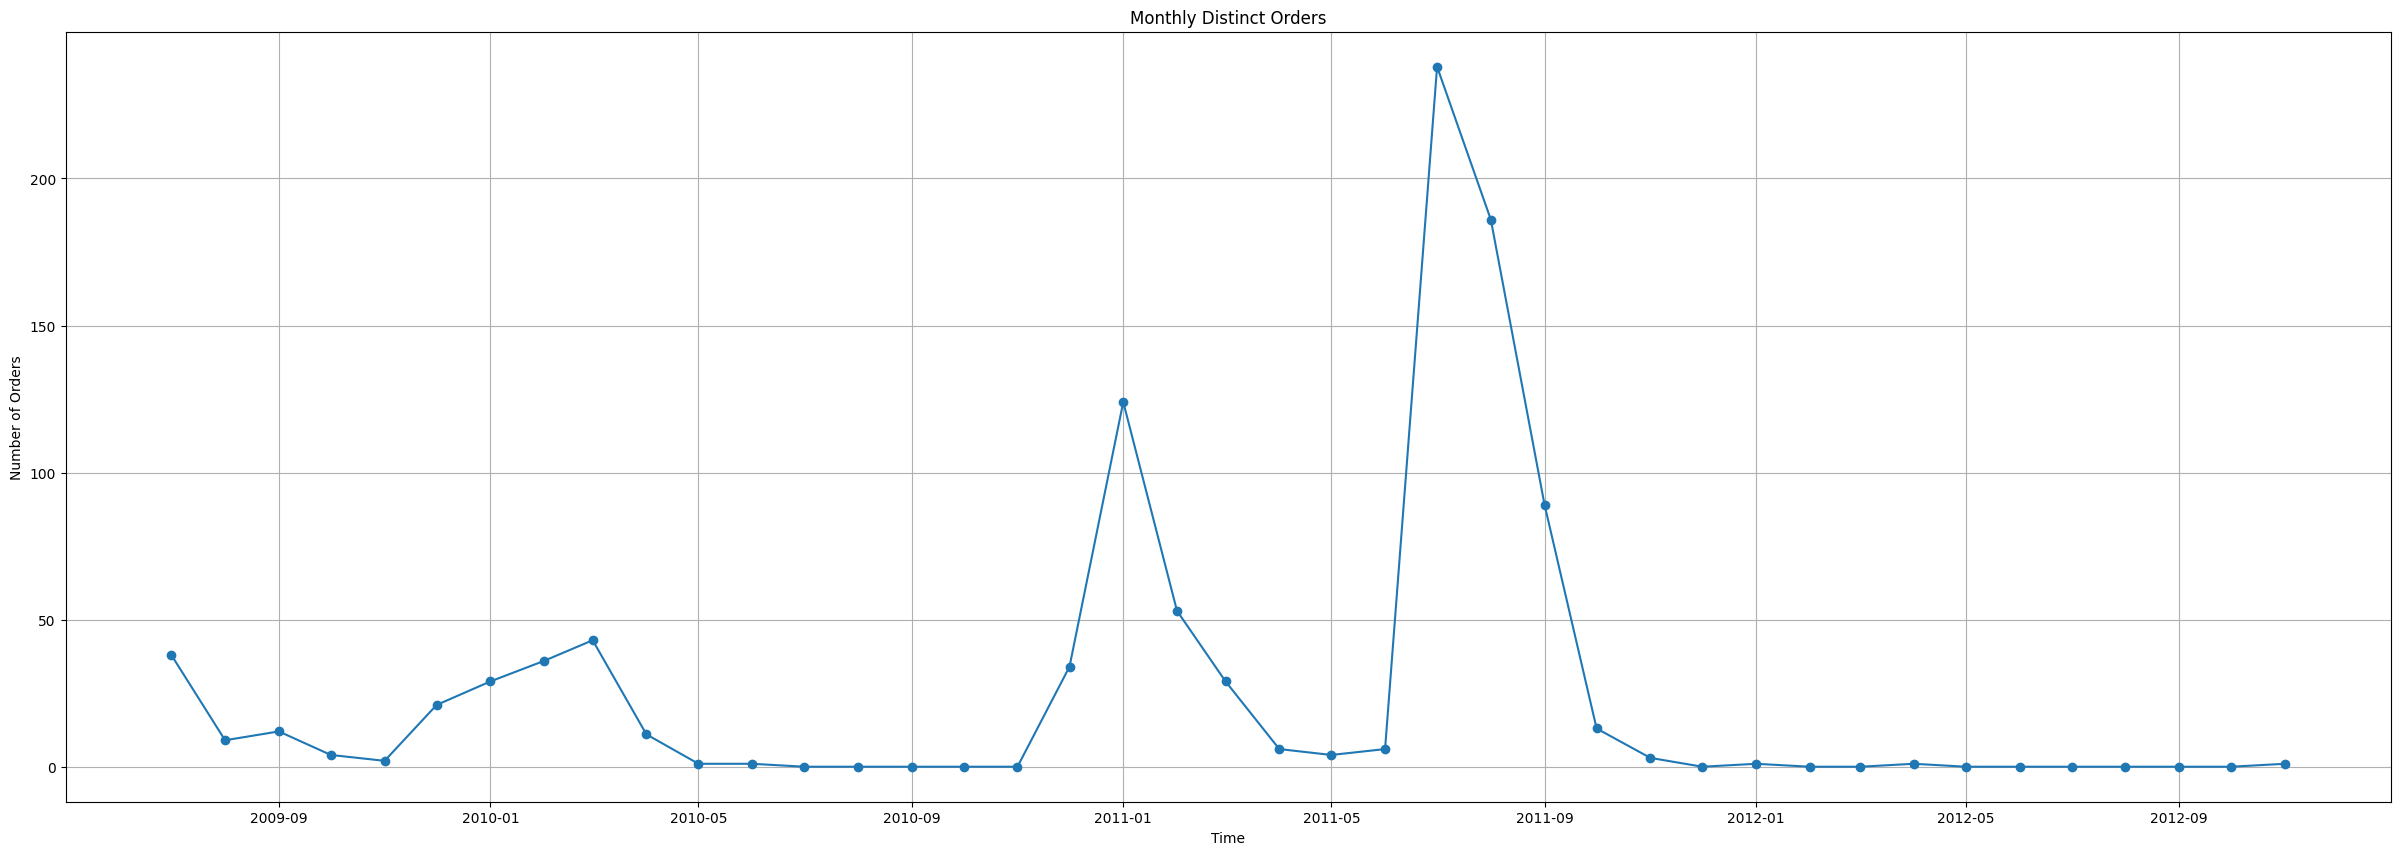

In [1098]:
# Visualize the monthly distinct orders
plt.figure(figsize=(30, 10))
plt.plot(monthly_orders['Distinct Orders'], marker='o', linestyle='-')
plt.title('Monthly Distinct Orders')
plt.xlabel('Time')
plt.ylabel('Number of Orders')
plt.grid()
plt.show()

In [1099]:
# Optimize SARIMA Parameters
auto_model = auto_arima(
    monthly_orders['Distinct Orders'],
    start_p=1, start_q=1,
    max_p=3, max_q=3,
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    seasonal=True, m=12,  # Seasonal period = 12 for monthly data
    d=1, D=1,
    enforce_stationarity=True,
    trace=True,
    suppress_warnings=True
)

# Extract optimal parameters
p, d, q = auto_model.order
P, D, Q, m = auto_model.seasonal_order

print(f"Optimal ARIMA parameters: {p, d, q}")
print(f"Optimal Seasonal parameters: {P, D, Q, m}")

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=inf, Time=0.14 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=326.113, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=inf, Time=0.15 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=0.21 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=inf, Time=0.09 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=inf, Time=0.18 sec
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=301.462, Time=0.23 sec
 ARIMA(0,1,0)(2,1,1)[12]             : AIC=inf, Time=0.37 sec
 ARIMA(0,1,0)(1,1,2)[12]             : AIC=inf, Time=0.53 sec
 ARIMA(0,1,0)(0,1,2)[12]             : AIC=inf, Time=0.38 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=inf, Time=0.38 sec
 ARIMA(0,1,0)(2,1,2)[12]             : AIC=inf, Time=0.55 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=300.295, Time=0.26 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=inf, Time=0.18 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=0.49 sec
 ARIMA(1,1,0)(1

In [1100]:
# Fit the SARIMA Model
sarima_model = SARIMAX(
    monthly_orders['Distinct Orders'],
    order=(p, d, q),
    seasonal_order=(P, D, Q, m),
    enforce_stationarity=True
)
sarima_fit = sarima_model.fit(disp=False)

# Forecasting
forecast = sarima_fit.get_forecast(steps=12)
forecast_values = forecast.predicted_mean.clip(lower=0)  # Clip negative predictions to zero
conf_int = forecast.conf_int()

/Users/priyachaudhuri/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/priyachaudhuri/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/priyachaudhuri/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


/var/folders/kv/6kn50zx13db29c7_5l_npqc40000gn/T/ipykernel_18725/2313988463.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_values.index = pd.date_range(start=forecast_start_date, periods=12, freq='M')


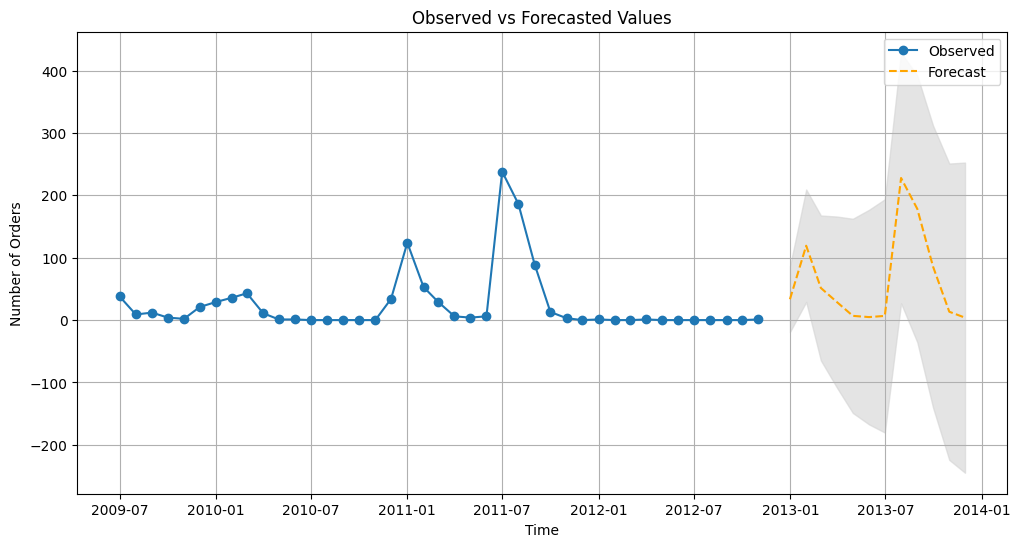

In [1101]:
# Correct forecast timeline alignment
forecast_start_date = monthly_orders.index[-1] + pd.DateOffset(months=1)  # Start from next month
forecast_end_date = forecast_start_date + pd.DateOffset(months=11)  # Forecast for 12 months
forecast_values.index = pd.date_range(start=forecast_start_date, periods=12, freq='M')

# Plot Forecast
plt.figure(figsize=(12, 6))
plt.plot(monthly_orders['Distinct Orders'], label='Observed', marker='o')
plt.plot(forecast_values.index, forecast_values, label='Forecast', linestyle='--', color='orange')
plt.fill_between(forecast_values.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='lightgrey', alpha=0.6)
plt.title('Observed vs Forecasted Values')
plt.xlabel('Time')
plt.ylabel('Number of Orders')
plt.legend()
plt.grid()
plt.show()

In [1102]:
# Fit the best SARIMA model using identified parameters
model_sarima = SARIMAX(monthly_orders['Distinct Orders'], order=(p, d, q),
                       seasonal_order=(P, D, Q, m))
model_fit = model_sarima.fit(disp=False)

# Print the model summary
model_fit.summary()

/Users/priyachaudhuri/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/priyachaudhuri/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/priyachaudhuri/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                     Distinct Orders   No. Observations:                   41
Model:             SARIMAX(0, 1, 1)x(1, 1, [], 12)   Log Likelihood                -146.102
Date:                             Mon, 09 Dec 2024   AIC                            298.204
Time:                                     14:33:26   BIC                            302.200
Sample:                                 07-01-2009   HQIC                           299.426
                                      - 11-01-2012                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.3956      0.251      1.576      0.115      -0.096       0.888
ar.S.L12      -0.9528      0.027    -35.955      0.000      -1.005      -0.901
sigma2       717.1833    196.726      3.646      0.000     331.607    1102.760
===================================================================================
Ljung-Box (L1) (Q):                   0.19   Jarque-Bera (JB):                21.58
Prob(Q):                              0.66   Prob(JB):                         0.00
Heteroskedasticity (H):               0.79   Skew:                            -0.16
Prob(H) (two-sided):                  0.73   Kurtosis:                         7.29
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

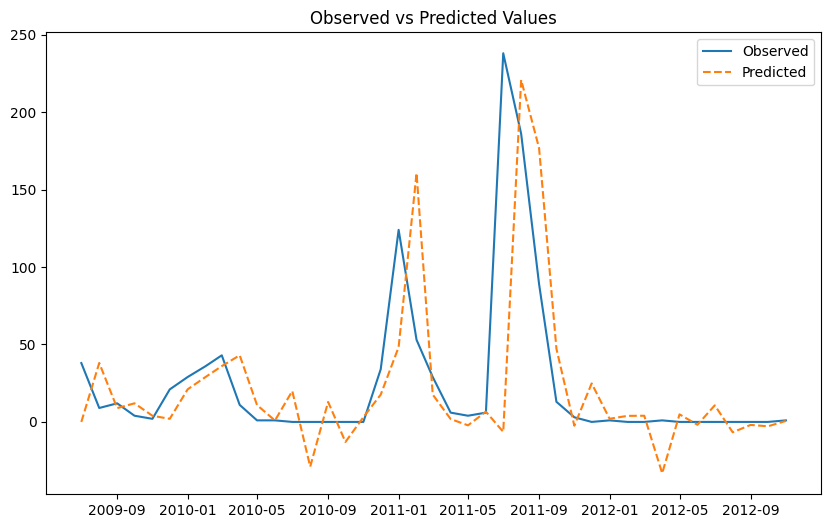

In [1103]:
# Predict over the entire dataset
y_hat = model_fit.predict(start=monthly_orders.index[0], end=monthly_orders.index[-1])

# Plot observed vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(monthly_orders['Distinct Orders'], label="Observed")
plt.plot(y_hat, label="Predicted", linestyle='--')
plt.title("Observed vs Predicted Values")
plt.legend()
plt.show()

In [1104]:
# Temporal splitting
train_size = int(len(monthly_orders) * 0.8)  # 80% for training
train_data = monthly_orders.iloc[:train_size]
test_data = monthly_orders.iloc[train_size:]

# Fit SARIMA model on training data
# model = SARIMAX(train_data['Distinct Orders'], order=(0, 1, 0), seasonal_order=(0, 0, 0, 12), enforce_stationarity=True, enforce_invertibility=False)
# sarima_model = model.fit(disp=False)

# Fit the SARIMA Model
sarima_model = SARIMAX(
    train_data['Distinct Orders'],
    order=(p, d, q),
    seasonal_order=(P, D, Q, m),
    enforce_stationarity=True
)
sarima_fit = sarima_model.fit(disp=False)

# Forecasting
forecast = sarima_fit.get_forecast(steps=len(test_data))
forecast_values = forecast.predicted_mean.clip(lower=0)  # Clip negative predictions to zero
conf_int = forecast.conf_int()

# Forecast for the testing period
# forecast = sarima_model.get_forecast(steps=len(test_data))
# forecast_values = forecast.predicted_mean

# Actual values from the test set
actual_values = test_data['Distinct Orders'].values

# Calculate evaluation metrics
mae = mean_absolute_error(actual_values, forecast_values)
mse = mean_squared_error(actual_values, forecast_values)
rmse = np.sqrt(mse)

# Print evaluation metrics
print("Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

Evaluation Metrics:
Mean Absolute Error (MAE): 0.6759283124233966
Mean Squared Error (MSE): 2.0748651687929476
Root Mean Squared Error (RMSE): 1.4404392277333145


/Users/priyachaudhuri/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/priyachaudhuri/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/priyachaudhuri/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


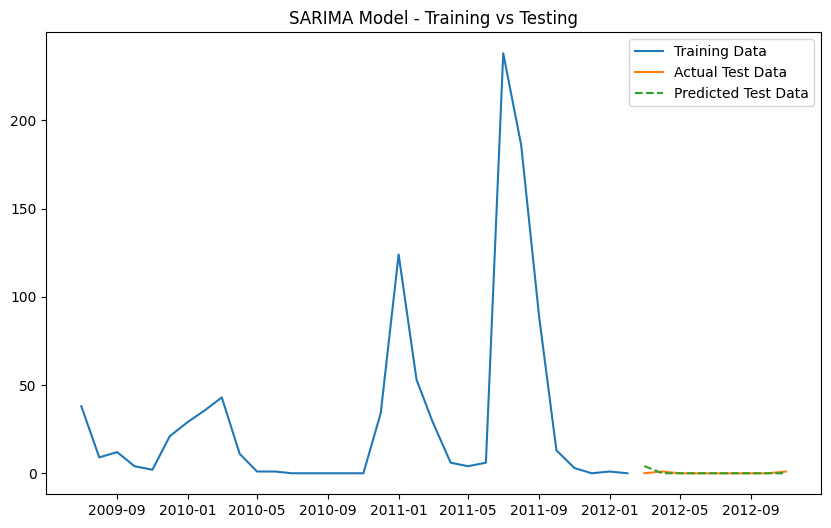

In [1105]:
plt.figure(figsize=(10, 6))
plt.plot(train_data.index, train_data['Distinct Orders'], label="Training Data")
plt.plot(test_data.index, test_data['Distinct Orders'], label="Actual Test Data")
plt.plot(test_data.index, forecast_values, label="Predicted Test Data", linestyle="--")
plt.legend()
plt.title("SARIMA Model - Training vs Testing")
plt.show()

In [1106]:
# Forecast for 5-month and 2-month horizons
forecast_5_months = model_fit.get_forecast(steps=5)
forecast_2_months = model_fit.get_forecast(steps=2)

forecast_5_values = forecast_5_months.predicted_mean
forecast_2_values = forecast_2_months.predicted_mean

In [1107]:
print(forecast_5_values)
print(forecast_2_values)

2012-12-01     33.395312
2013-01-01    119.197485
2013-02-01     51.499147
2013-03-01     28.631145
2013-04-01      6.763144
Freq: MS, Name: predicted_mean, dtype: float64
2012-12-01     33.395312
2013-01-01    119.197485
Freq: MS, Name: predicted_mean, dtype: float64


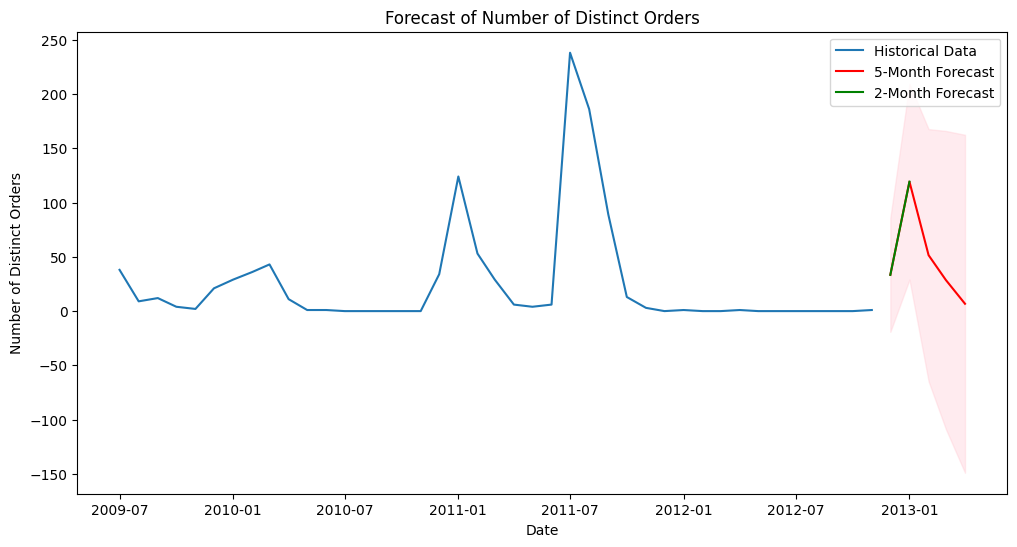

In [1108]:
# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(monthly_orders, label='Historical Data')
plt.plot(forecast_5_values.index, forecast_5_values, label='5-Month Forecast', color='red')
plt.plot(forecast_2_values.index, forecast_2_values, label='2-Month Forecast', color='green')
plt.fill_between(forecast_5_values.index,
                 forecast_5_months.conf_int().iloc[:, 0],
                 forecast_5_months.conf_int().iloc[:, 1], color='pink', alpha=0.3)
plt.title('Forecast of Number of Distinct Orders')
plt.xlabel('Date')
plt.ylabel('Number of Distinct Orders')
plt.legend()
plt.show()


# Item Demand

In [1109]:
data4 = data.copy()

In [1110]:
data4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2419 entries, 0 to 2419
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Order Date               2419 non-null   datetime64[ns]
 1   Requested Delivery Date  2419 non-null   datetime64[ns]
 2   Customer Country Code    2419 non-null   object        
 3   Product Code             2419 non-null   object        
 4   Description              2419 non-null   object        
 5   Order Type               2419 non-null   object        
 6   Customer Order Code      2419 non-null   int64         
 7   Value                    2419 non-null   float64       
 8   Currency                 2419 non-null   object        
 9   Items                    2419 non-null   int64         
 10  Route                    2419 non-null   object        
 11  Lead Time                2419 non-null   int64         
 12  Order Day                2419 non-null 

In [1111]:
data4.head(5)

,Order Date,Requested Delivery Date,Customer Country Code,Product Code,Description,Order Type,Customer Order Code,Value,Currency,Items,Route,Lead Time,Order Day,Order Month,Order Year,O_Season,O_Season_Num
0,2009-07-13,2010-01-28,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435553,2337.00,RUB,6,RU0001,199,13,7,2009,Summer,3
1,2009-07-15,2010-03-24,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435694,10160.25,RUB,23,RU0001,252,15,7,2009,Summer,3
2,2009-07-16,2010-02-04,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435741,2992.50,RUB,7,RU0001,203,16,7,2009,Summer,3
3,2009-07-17,2010-02-04,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435907,4061.25,RUB,9,RU0001,202,17,7,2009,Summer,3
4,2009-07-21,2010-02-01,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435963,2208.75,RUB,5,RU0001,195,21,7,2009,Summer,3


In [1112]:
data4['Route'].value_counts()

Route
RU0001    637
1         191
FR0001    169
AT0003    165
FR01SI    148
CH0001    147
FR01DE    136
FR01CH    130
FR01CZ    104
FI0003     92
IT0000     65
FI01FR     64
SP0003     51
DE0005     34
PT0001     25
FR01NL     24
FR02RO     24
DK01FR     21
FR02UA     19
NO02FR     19
FR02EE     18
FR02GR     18
BE0001     17
FR02BG     16
SI0001     14
AD0001     14
CZ0002     13
FR02BY     12
SE02FR     12
AL0002      7
RO1001      6
FR02KZ      4
CE5001      2
GB0005      1
Name: count, dtype: int64

In [1113]:
data4[data4['Route'] == '1']

,Order Date,Requested Delivery Date,Customer Country Code,Product Code,Description,Order Type,Customer Order Code,Value,Currency,Items,Route,Lead Time,Order Day,Order Month,Order Year,O_Season,O_Season_Num
440,2011-03-09,2011-09-05,SK,L12134400,Parka Outdoor Lifestyle STD,VO,3200700738,30.46,EUR,3,1,180,9,3,2011,Spring,2
441,2011-03-16,2011-10-03,SK,L12134400,Parka Outdoor Lifestyle STD,VO,3200700760,62.94,EUR,6,1,201,16,3,2011,Spring,2
447,2011-02-02,2011-08-01,PL,L12134400,Parka Outdoor Lifestyle STD,VO,3200702354,168.56,PLN,4,1,180,2,2,2011,Winter,1
448,2011-02-02,2011-08-01,PL,L12134400,Parka Outdoor Lifestyle STD,VO,3200702365,337.12,PLN,8,1,180,2,2,2011,Winter,1
449,2011-02-07,2011-08-01,PL,L12134400,Parka Outdoor Lifestyle STD,VO,3200702462,168.56,PLN,4,1,175,7,2,2011,Winter,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2343,2011-07-25,2012-03-01,SK,L12919200,Parka Outdoor Lifestyle STD,VO,3200716945,42.52,EUR,4,1,220,25,7,2011,Summer,3
2350,2011-08-01,2012-03-13,PL,L12919200,Parka Outdoor Lifestyle STD,VO,3200720980,151.52,PLN,4,1,225,1,8,2011,Summer,3
2351,2011-08-02,2012-03-01,PL,L12919200,Parka Outdoor Lifestyle STD,VO,3200721404,549.50,PLN,14,1,212,2,8,2011,Summer,3
2364,2011-08-18,2012-06-01,SK,L12919200,Parka Outdoor Lifestyle STD,VO,3200730897,22.26,EUR,2,1,288,18,8,2011,Summer,3


In [1114]:
#data4 = data4[data4['Route'] != '1']

In [1115]:
data4['Route'].value_counts()

Route
RU0001    637
1         191
FR0001    169
AT0003    165
FR01SI    148
CH0001    147
FR01DE    136
FR01CH    130
FR01CZ    104
FI0003     92
IT0000     65
FI01FR     64
SP0003     51
DE0005     34
PT0001     25
FR01NL     24
FR02RO     24
DK01FR     21
FR02UA     19
NO02FR     19
FR02EE     18
FR02GR     18
BE0001     17
FR02BG     16
SI0001     14
AD0001     14
CZ0002     13
FR02BY     12
SE02FR     12
AL0002      7
RO1001      6
FR02KZ      4
CE5001      2
GB0005      1
Name: count, dtype: int64

In [1116]:
data4['Items'].describe()

count    2419.000000
mean        7.106656
std        18.412228
min         0.000000
25%         3.000000
50%         5.000000
75%         8.000000
max       410.000000
Name: Items, dtype: float64

In [1117]:
data4['Items'].dtypes

dtype('int64')

In [1118]:
# Binning demand into quartiles for classification
low, mid, mid_high, high = data4['Items'].quantile([0.25,0.5,0.75,1])

In [1119]:
print(low, mid, mid_high, high)

3.0 5.0 8.0 410.0


In [1120]:
def demand_class(row):
    if row < low:
        return 4
    elif row >= low and row < mid:
        return 3
    elif row >= mid and row < mid_high:
        return 2
    else:
        return 1

data4['Demand Class'] = data4['Items'].map(demand_class)

In [1121]:
data4['Demand Class'].value_counts()

Demand Class
2    726
1    624
4    560
3    509
Name: count, dtype: int64

In [1122]:
data4.columns

Index(['Order Date', 'Requested Delivery Date', 'Customer Country Code',
       'Product Code', 'Description', 'Order Type', 'Customer Order Code',
       'Value', 'Currency', 'Items', 'Route', 'Lead Time', 'Order Day',
       'Order Month', 'Order Year', 'O_Season', 'O_Season_Num',
       'Demand Class'],
      dtype='object')

In [1123]:
# Encoding categorical variables (excluding 'Description' as requested), Check to see if 'Order Type', Route has to be included in features
data4 = pd.get_dummies(data4, columns=['Customer Country Code', 'Product Code', 'Currency', 'Route'], drop_first=True)

In [1124]:
data4.columns

Index(['Order Date', 'Requested Delivery Date', 'Description', 'Order Type',
       'Customer Order Code', 'Value', 'Items', 'Lead Time', 'Order Day',
       'Order Month',
       ...
       'Route_FR02UA', 'Route_GB0005', 'Route_IT0000', 'Route_NO02FR',
       'Route_PT0001', 'Route_RO1001', 'Route_RU0001', 'Route_SE02FR',
       'Route_SI0001', 'Route_SP0003'],
      dtype='object', length=124)

In [1125]:
data4['Description'].value_counts()

Description
Parka Outdoor Lifestyle STD    2419
Name: count, dtype: int64

In [1126]:
# Features and target variable (excluding 'Description')
X = data4.drop(columns = ['Order Date', 'Requested Delivery Date', 'Order Type', 'O_Season', 'Description',
       'Customer Order Code', 'Demand Class', 'Value', 'Items', 'Order Day', 'Order Month', 'Order Year'])

y = data4['Demand Class']

In [1127]:
# Train and Test Split 5-Month Horizon
X_train_5, X_test_5, y_train_5, y_test_5 = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X, y, test_size=0.2, random_state=42)

# Order Date-Based Time Horizon Splits
data_test = data4.loc[X_test_5.index]
last_date = data_test['Order Date'].max()

# 5-Month Horizon: Orders from the last 5 months
# 12/31 - 5month = 07/31
# 07/31 - 12/31
horizon_5months = last_date - pd.DateOffset(months=5)
test_5_month = data_test[(data_test['Order Date'] >= horizon_5months)]
X_test_5_month = X_test_5.loc[test_5_month.index]
y_test_5_month = y_test_5.loc[test_5_month.index]

# Order Date-Based Time Horizon Splits
data_test = data4.loc[X_test_2.index]
last_date = data_test['Order Date'].max()

# 2-Month Horizon: Orders from the last 2 months
horizon_2months = last_date - pd.DateOffset(months=2)
test_2_month = data_test[(data_test['Order Date'] >= horizon_2months)]
X_test_2_month = X_test_2.loc[test_2_month.index]
y_test_2_month = y_test_2.loc[test_2_month.index]

In [1128]:
# Logistic Regression for 5-month
log_reg_5 = LogisticRegression(max_iter=1000 , random_state=42)

log_reg_5.fit(X_train_5, y_train_5)
y_pred_5 = log_reg_5.predict(X_test_5_month)
accuracy_5 = accuracy_score(y_test_5_month, y_pred_5)
report_5 = classification_report(y_test_5_month, y_pred_5)


/Users/priyachaudhuri/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [1129]:
# Logistic Regression for 2-month
log_reg_2 = LogisticRegression(max_iter=1000 , random_state=42)
log_reg_2.fit(X_train_2, y_train_2)
y_pred_2 = log_reg_2.predict(X_test_2_month)
accuracy_2 = accuracy_score(y_test_2_month, y_pred_2)
report_2 = classification_report(y_test_2_month, y_pred_2)


/Users/priyachaudhuri/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [1130]:
# Evaluation Metrics for 5-Month Horizon
print(accuracy_5)
print( report_5)

0.3950617283950617
              precision    recall  f1-score   support

           1       0.20      0.25      0.22         4
           2       0.55      0.31      0.40        35
           3       0.35      0.67      0.46        24
           4       0.40      0.22      0.29        18

    accuracy                           0.40        81
   macro avg       0.37      0.36      0.34        81
weighted avg       0.44      0.40      0.38        81



In [1131]:
# Evaluation Metrics for 2-Month Horizon
print(accuracy_2)
print(report_2)

1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1



In [1132]:

from sklearn.ensemble import RandomForestClassifier 
# Random Forest model

rf_model_5 = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model_5.fit(X_train_5, y_train_5)
y_pred_5 = rf_model_5.predict(X_test_5_month)
accuracy_5 = accuracy_score(y_test_5_month, y_pred_5)
report_5 = classification_report(y_test_5_month, y_pred_5)

In [1133]:
# Evaluation Metrics for 5-Month Horizon
print(accuracy_5)
print( report_5)

0.5308641975308642
              precision    recall  f1-score   support

           1       0.14      0.25      0.18         4
           2       0.68      0.66      0.67        35
           3       0.42      0.42      0.42        24
           4       0.56      0.50      0.53        18

    accuracy                           0.53        81
   macro avg       0.45      0.46      0.45        81
weighted avg       0.55      0.53      0.54        81



In [1134]:
rf_model_2 = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model_2.fit(X_train_2, y_train_2)
y_pred_2 = rf_model_5.predict(X_test_2_month)
accuracy_2 = accuracy_score(y_test_2_month, y_pred_2)
report_2 = classification_report(y_test_2_month, y_pred_2)

In [1135]:
# Evaluation Metrics for 5-Month Horizon
print(accuracy_2)
print( report_2)

1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1



# Quantity Demand

In [1136]:
data1 = data.copy()
# Calculate empirical quantiles for Lead Time by Product Code
quantile_results = data1.groupby('Product Code')['Items'].agg(
    mean_items='mean',
    median_items='median',
    std_items='std',
    q25_items=lambda x: x.quantile(0.25),
    q50_items=lambda x: x.quantile(0.5),
    q75_items=lambda x: x.quantile(0.75)).reset_index()

In [1137]:
# Merge quantile data to main DataFrame
data1 = data1.merge(quantile_results, on='Product Code', how='left')

In [1138]:
data1.head()

,Order Date,Requested Delivery Date,Customer Country Code,Product Code,Description,Order Type,Customer Order Code,Value,Currency,Items,...,Order Month,Order Year,O_Season,O_Season_Num,mean_items,median_items,std_items,q25_items,q50_items,q75_items
0,2009-07-13,2010-01-28,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435553,2337.00,RUB,6,...,7,2009,Summer,3,8.16,6.0,10.031949,5.0,6.0,8.0
1,2009-07-15,2010-03-24,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435694,10160.25,RUB,23,...,7,2009,Summer,3,8.16,6.0,10.031949,5.0,6.0,8.0
2,2009-07-16,2010-02-04,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435741,2992.50,RUB,7,...,7,2009,Summer,3,8.16,6.0,10.031949,5.0,6.0,8.0
3,2009-07-17,2010-02-04,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435907,4061.25,RUB,9,...,7,2009,Summer,3,8.16,6.0,10.031949,5.0,6.0,8.0
4,2009-07-21,2010-02-01,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435963,2208.75,RUB,5,...,7,2009,Summer,3,8.16,6.0,10.031949,5.0,6.0,8.0


In [1139]:
quantile_results

,Product Code,mean_items,median_items,std_items,q25_items,q50_items,q75_items
0,L10705000,8.160000,6.0,10.031949,5.00,6.0,8.00
1,L10705100,9.500000,9.0,3.836955,6.50,9.0,12.25
2,L10705200,7.928571,6.0,3.751190,5.00,6.0,10.00
3,L10705300,10.823529,7.0,11.215142,5.00,7.0,10.00
4,L10705400,9.000000,7.0,9.339476,0.00,7.0,11.50
5,L10705500,10.285714,8.5,6.450147,5.25,8.5,12.75
6,L10705600,7.791667,7.5,4.149166,5.00,7.5,8.00
7,L10705700,7.100000,6.5,4.040077,4.25,6.5,7.75
8,L10850600,8.227273,5.0,11.124188,3.00,5.0,10.00
9,L10850700,3.071429,2.0,2.432608,1.00,2.0,4.75


## Random Forest Model

In [1140]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2419 entries, 0 to 2418
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Order Date               2419 non-null   datetime64[ns]
 1   Requested Delivery Date  2419 non-null   datetime64[ns]
 2   Customer Country Code    2419 non-null   object        
 3   Product Code             2419 non-null   object        
 4   Description              2419 non-null   object        
 5   Order Type               2419 non-null   object        
 6   Customer Order Code      2419 non-null   int64         
 7   Value                    2419 non-null   float64       
 8   Currency                 2419 non-null   object        
 9   Items                    2419 non-null   int64         
 10  Route                    2419 non-null   object        
 11  Lead Time                2419 non-null   int64         
 12  Order Day                2419 non-

In [1141]:
# Encode categorical variables
data1 = pd.get_dummies(data1, columns=['Customer Country Code', 'Product Code', 'Currency'], drop_first=True)

In [1142]:
data1.head()

,Order Date,Requested Delivery Date,Description,Order Type,Customer Order Code,Value,Items,Route,Lead Time,Order Day,...,Product Code_L12919100,Product Code_L12919200,Currency_CZK,Currency_DKK,Currency_EUR,Currency_GBP,Currency_NOK,Currency_PLN,Currency_RUB,Currency_SEK
0,2009-07-13,2010-01-28,Parka Outdoor Lifestyle STD,VO,3200435553,2337.00,6,RU0001,199,13,...,False,False,False,False,False,False,False,False,True,False
1,2009-07-15,2010-03-24,Parka Outdoor Lifestyle STD,VO,3200435694,10160.25,23,RU0001,252,15,...,False,False,False,False,False,False,False,False,True,False
2,2009-07-16,2010-02-04,Parka Outdoor Lifestyle STD,VO,3200435741,2992.50,7,RU0001,203,16,...,False,False,False,False,False,False,False,False,True,False
3,2009-07-17,2010-02-04,Parka Outdoor Lifestyle STD,VO,3200435907,4061.25,9,RU0001,202,17,...,False,False,False,False,False,False,False,False,True,False
4,2009-07-21,2010-02-01,Parka Outdoor Lifestyle STD,VO,3200435963,2208.75,5,RU0001,195,21,...,False,False,False,False,False,False,False,False,True,False


In [1143]:
# Step 2: Define Features and Target
# Split the data into training and testing sets
X = data1.drop(columns = ['Order Date', 'Requested Delivery Date', 'Description', 'Order Type', 'O_Season',
       'Customer Order Code', 'Value', 'Items', 'Route', 'Order Day', 'Order Month', 'Order Year'])
y = data1['Items']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [1144]:
# Step 3: Train the Random Forest Regressor
regressor = RandomForestRegressor(random_state=42, n_estimators=50, n_jobs=-1)
regressor.fit(X_train, y_train)

RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42)

In [1145]:
# Step 4: Evaluate the Model
y_pred = regressor.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

Mean Absolute Error (MAE): 4.704956888876566
Mean Squared Error (MSE): 224.10583686939668
Root Mean Squared Error (RMSE): 14.970164891189297


In [1146]:
# Step 5: Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': regressor.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Display the feature importance
print(feature_importance)


                     Feature    Importance
0                  Lead Time  4.598369e-01
1               O_Season_Num  1.897033e-01
79              Currency_EUR  6.781158e-02
2                 mean_items  4.123827e-02
54    Product Code_L12134600  2.684036e-02
..                       ...           ...
23  Customer Country Code_GL  5.383066e-06
51    Product Code_L10853100  4.214181e-06
46    Product Code_L10850700  2.926372e-06
22  Customer Country Code_GB  8.601872e-07
80              Currency_GBP  1.333708e-07

[85 rows x 2 columns]


### 5 Month & 2 Month Filter - Regression

In [1147]:
# # Train and Test Split 5-Month Horizon
# X_train_5, X_test_5, y_train_5, y_test_5 = train_test_split(X, y, test_size=0.2, random_state=42)
# X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X, y, test_size=0.2, random_state=42)

# # Order Date-Based Time Horizon Splits
# data_test = data1.loc[X_test_5.index]
# last_date = data_test['Order Date'].max()

# # 5-Month Horizon: Orders from the last 5 months
# # 12/31 - 5month = 07/31
# # 07/31 - 12/31
# horizon_5months = last_date - pd.DateOffset(months=5)
# test_5_month = data_test[(data_test['Order Date'] >= horizon_5months)]
# X_test_5_month = X_test_5.loc[test_5_month.index]
# y_test_5_month = y_test_5.loc[test_5_month.index]

# # Order Date-Based Time Horizon Splits
# data_test = data1.loc[X_test_2.index]
# last_date = data_test['Order Date'].max()

# # 2-Month Horizon: Orders from the last 2 months
# horizon_2months = last_date - pd.DateOffset(months=2)
# test_2_month = data_test[(data_test['Order Date'] >= horizon_2months)]
# X_test_2_month = X_test_2.loc[test_2_month.index]
# y_test_2_month = y_test_2.loc[test_2_month.index]

In [1148]:
# Step 2: Define a Function to Train and Evaluate the Model
def train_and_evaluate(horizon):

    if horizon == 2:
        X_train, X_test_2, y_train, y_test_2 = train_test_split(X, y, test_size=0.2, random_state=42)
        data_test = data1.loc[X_test_2.index]
        last_date = data_test['Order Date'].max()
        # 2-Month Horizon: Orders from the last 2 months
        horizon_2months = last_date - pd.DateOffset(months=2)
        test_2_month = data_test[(data_test['Order Date'] >= horizon_2months)]
        X_test = X_test_2.loc[test_2_month.index]
        y_test = y_test_2.loc[test_2_month.index]
    elif horizon == 5:
        X_train, X_test_5, y_train, y_test_5 = train_test_split(X, y, test_size=0.2, random_state=42)
        # Order Date-Based Time Horizon Splits
        data_test = data1.loc[X_test_5.index]
        last_date = data_test['Order Date'].max()

        # 5-Month Horizon: Orders from the last 5 months
        # 12/31 - 5month = 07/31
        # 07/31 - 12/31
        horizon_5months = last_date - pd.DateOffset(months=5)
        test_5_month = data_test[(data_test['Order Date'] >= horizon_5months)]
        X_test = X_test_5.loc[test_5_month.index]
        y_test = y_test_5.loc[test_5_month.index]

    # Train the model
    regressor = RandomForestRegressor(random_state=42, n_estimators=50, n_jobs=-1)
    regressor.fit(X_train, y_train)

    # Make predictions
    y_pred = regressor.predict(X_test)

    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    print(f"--- {horizon}-Month Horizon ---")
    print(f"Mean Absolute Error (MAE): {mae}")
    print(f"Mean Squared Error (MSE): {mse}")
    print(f"Root Mean Squared Error (RMSE): {rmse}")

    return mae, mse, rmse, y_pred


In [1149]:
# Call the function for 5-month and 2-month horizons
results_5_months = train_and_evaluate(5)  # For 5-month horizon
results_2_months = train_and_evaluate(2)  # For 2-month horizon

--- 5-Month Horizon ---
Mean Absolute Error (MAE): 3.082707789601753
Mean Squared Error (MSE): 59.63723718260193
Root Mean Squared Error (RMSE): 7.722514951918314
--- 2-Month Horizon ---
Mean Absolute Error (MAE): 2.6100000000000003
Mean Squared Error (MSE): 6.812100000000002
Root Mean Squared Error (RMSE): 2.6100000000000003


In [1150]:
# Unpack the predictions
mae_5, mse_5, rmse_5, y_pred_5items = results_5_months
mae_2, mse_2, rmse_2, y_pred_2items = results_2_months

In [1151]:
y_pred_5items

array([ 4.54      ,  2.56      ,  2.078     ,  4.38      ,  8.22      ,
        6.699     ,  4.92      ,  3.648     ,  4.25      ,  3.86      ,
        5.83733333,  4.1       ,  5.16      ,  5.84607143,  1.57266667,
        5.66117647,  5.64      ,  4.44      ,  0.27      ,  5.41      ,
        3.075     ,  3.32      ,  6.94      ,  3.20944444,  7.22      ,
        6.98      ,  5.2786569 ,  3.        , 11.1       ,  5.26      ,
        7.        ,  9.38      ,  3.88      ,  3.48      ,  6.88      ,
        2.00102757,  5.24545455,  4.34529725,  3.02      ,  4.        ,
        7.14      ,  2.57006349,  4.34666667,  2.73      ,  4.9       ,
        6.08      ,  4.86      ,  2.2       ,  2.45333333,  1.29958333,
        6.98      ,  7.        ,  4.13672515, 13.225     ,  1.098     ,
        0.62      ,  3.96      ,  5.84      ,  2.02      ,  5.94      ,
        5.38      ,  1.81033333,  7.        ,  4.44      ,  3.615     ,
        4.68      , 11.49314286,  7.39      ,  3.16      ,  3.12

In [1152]:
y_pred_2items

array([7.39])

In [1153]:
# Step 3: Train and Evaluate Models for Both Horizons
print("Evaluating 5-Month Horizon...")
print(f"Mean Absolute Error (MAE): {mae_5}")
print(f"Mean Squared Error (MSE): {mse_5}")
print(f"Root Mean Squared Error (RMSE): {rmse_5}")

print("\nEvaluating 2-Month Horizon...")
print(f"Mean Absolute Error (MAE): {mae_2}")
print(f"Mean Squared Error (MSE): {mse_2}")
print(f"Root Mean Squared Error (RMSE): {rmse_2}")


Evaluating 5-Month Horizon...
Mean Absolute Error (MAE): 3.082707789601753
Mean Squared Error (MSE): 59.63723718260193
Root Mean Squared Error (RMSE): 7.722514951918314

Evaluating 2-Month Horizon...
Mean Absolute Error (MAE): 2.6100000000000003
Mean Squared Error (MSE): 6.812100000000002
Root Mean Squared Error (RMSE): 2.6100000000000003


# Lead Time

In [1154]:
data2 = data.copy()

In [1155]:
data2[['Order Date', 'Requested Delivery Date', 'Lead Time']].head()

,Order Date,Requested Delivery Date,Lead Time
0,2009-07-13,2010-01-28,199
1,2009-07-15,2010-03-24,252
2,2009-07-16,2010-02-04,203
3,2009-07-17,2010-02-04,202
4,2009-07-21,2010-02-01,195


### Define Quartiles

In [1156]:
# Calculate empirical quantiles for Lead Time by Product Code
lead_time_stats = data2.groupby('Product Code')['Lead Time'].agg(
    mean_lead_time='mean',
    median_lead_time='median',
    std_lead_time='std',
    q25_lead_time=lambda x: x.quantile(0.25),
    q75_lead_time=lambda x: x.quantile(0.75)).reset_index()

In [1157]:
# Merge quantile data to main DataFrame
data2 = data2.merge(lead_time_stats, on='Product Code', how='left')

### Data Preprocessing

In [1158]:
scaler = StandardScaler()
data2[['Value', 'Items']] = scaler.fit_transform(data[['Value', 'Items']])

In [1159]:
data2['Seasonality'] = data2['Order Date'].dt.month.map(month_to_season)

In [1160]:
data2.head()

,Order Date,Requested Delivery Date,Customer Country Code,Product Code,Description,Order Type,Customer Order Code,Value,Currency,Items,...,Order Month,Order Year,O_Season,O_Season_Num,mean_lead_time,median_lead_time,std_lead_time,q25_lead_time,q75_lead_time,Seasonality
0,2009-07-13,2010-01-28,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435553,0.458328,RUB,-0.060117,...,7,2009,Summer,3,196.84,195.0,18.551011,182.0,203.0,Summer
1,2009-07-15,2010-03-24,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435694,3.513705,RUB,0.863374,...,7,2009,Summer,3,196.84,195.0,18.551011,182.0,203.0,Summer
2,2009-07-16,2010-02-04,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435741,0.714334,RUB,-0.005794,...,7,2009,Summer,3,196.84,195.0,18.551011,182.0,203.0,Summer
3,2009-07-17,2010-02-04,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435907,1.131735,RUB,0.102852,...,7,2009,Summer,3,196.84,195.0,18.551011,182.0,203.0,Summer
4,2009-07-21,2010-02-01,RU,L10705000,Parka Outdoor Lifestyle STD,VO,3200435963,0.408240,RUB,-0.114440,...,7,2009,Summer,3,196.84,195.0,18.551011,182.0,203.0,Summer


In [1161]:
data2 = pd.get_dummies(data2, columns=['Customer Country Code', 'Order Type', 'Currency', 'Route'], drop_first=True)

In [1162]:
data2.head(10)

,Order Date,Requested Delivery Date,Product Code,Description,Customer Order Code,Value,Items,Lead Time,Order Day,Order Month,...,Route_FR02UA,Route_GB0005,Route_IT0000,Route_NO02FR,Route_PT0001,Route_RO1001,Route_RU0001,Route_SE02FR,Route_SI0001,Route_SP0003
0,2009-07-13,2010-01-28,L10705000,Parka Outdoor Lifestyle STD,3200435553,0.458328,-0.060117,199,13,7,...,False,False,False,False,False,False,True,False,False,False
1,2009-07-15,2010-03-24,L10705000,Parka Outdoor Lifestyle STD,3200435694,3.513705,0.863374,252,15,7,...,False,False,False,False,False,False,True,False,False,False
2,2009-07-16,2010-02-04,L10705000,Parka Outdoor Lifestyle STD,3200435741,0.714334,-0.005794,203,16,7,...,False,False,False,False,False,False,True,False,False,False
3,2009-07-17,2010-02-04,L10705000,Parka Outdoor Lifestyle STD,3200435907,1.131735,0.102852,202,17,7,...,False,False,False,False,False,False,True,False,False,False
4,2009-07-21,2010-02-01,L10705000,Parka Outdoor Lifestyle STD,3200435963,0.408240,-0.114440,195,21,7,...,False,False,False,False,False,False,True,False,False,False
5,2009-07-20,2010-02-01,L10705000,Parka Outdoor Lifestyle STD,3200435982,0.394325,-0.114440,196,20,7,...,False,False,False,False,False,False,True,False,False,False
6,2009-07-20,2010-01-28,L10705000,Parka Outdoor Lifestyle STD,3200436075,0.851613,0.048529,192,20,7,...,False,False,False,False,False,False,True,False,False,False
7,2009-07-20,2010-02-01,L10705000,Parka Outdoor Lifestyle STD,3200436082,0.779263,-0.005794,196,20,7,...,False,False,False,False,False,False,True,False,False,False
8,2009-07-21,2010-02-04,L10705000,Parka Outdoor Lifestyle STD,3200436158,2.306024,0.483113,198,21,7,...,False,False,False,False,False,False,True,False,False,False
9,2009-07-21,2010-02-01,L10705000,Parka Outdoor Lifestyle STD,3200436332,0.541808,-0.060117,195,21,7,...,False,False,False,False,False,False,True,False,False,False


In [1163]:
data2.columns

Index(['Order Date', 'Requested Delivery Date', 'Product Code', 'Description',
       'Customer Order Code', 'Value', 'Items', 'Lead Time', 'Order Day',
       'Order Month', 'Order Year', 'O_Season', 'O_Season_Num',
       'mean_lead_time', 'median_lead_time', 'std_lead_time', 'q25_lead_time',
       'q75_lead_time', 'Seasonality', 'Customer Country Code_AT',
       'Customer Country Code_BE', 'Customer Country Code_BG',
       'Customer Country Code_BY', 'Customer Country Code_CE',
       'Customer Country Code_CH', 'Customer Country Code_CY',
       'Customer Country Code_CZ', 'Customer Country Code_DE',
       'Customer Country Code_DK', 'Customer Country Code_EE',
       'Customer Country Code_ES', 'Customer Country Code_FI',
       'Customer Country Code_FR', 'Customer Country Code_GB',
       'Customer Country Code_GL', 'Customer Country Code_GR',
       'Customer Country Code_HR', 'Customer Country Code_IT',
       'Customer Country Code_NL', 'Customer Country Code_NO',
       

## Data Modelling - Linear Regression

In [1164]:
X = data2.drop(columns=['Product Code', 'Order Date', 'Requested Delivery Date', 'Lead Time', 'Customer Order Code', 'Description', 'O_Season', 'Seasonality'])
y = data2['Lead Time']

In [1165]:
X.columns

Index(['Value', 'Items', 'Order Day', 'Order Month', 'Order Year',
       'O_Season_Num', 'mean_lead_time', 'median_lead_time', 'std_lead_time',
       'q25_lead_time', 'q75_lead_time', 'Customer Country Code_AT',
       'Customer Country Code_BE', 'Customer Country Code_BG',
       'Customer Country Code_BY', 'Customer Country Code_CE',
       'Customer Country Code_CH', 'Customer Country Code_CY',
       'Customer Country Code_CZ', 'Customer Country Code_DE',
       'Customer Country Code_DK', 'Customer Country Code_EE',
       'Customer Country Code_ES', 'Customer Country Code_FI',
       'Customer Country Code_FR', 'Customer Country Code_GB',
       'Customer Country Code_GL', 'Customer Country Code_GR',
       'Customer Country Code_HR', 'Customer Country Code_IT',
       'Customer Country Code_NL', 'Customer Country Code_NO',
       'Customer Country Code_PL', 'Customer Country Code_PT',
       'Customer Country Code_RO', 'Customer Country Code_RU',
       'Customer Country Code_

In [1166]:
# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [1167]:
X_train

,Value,Items,Order Day,Order Month,Order Year,O_Season_Num,mean_lead_time,median_lead_time,std_lead_time,q25_lead_time,...,Route_FR02UA,Route_GB0005,Route_IT0000,Route_NO02FR,Route_PT0001,Route_RO1001,Route_RU0001,Route_SE02FR,Route_SI0001,Route_SP0003
1669,0.432942,0.157175,2,8,2011,3,244.687023,239.0,47.901997,216.00,...,False,False,False,False,False,False,False,False,False,False
1566,-0.411347,0.211498,31,8,2011,3,209.566667,215.0,38.219958,189.00,...,False,False,False,False,False,False,False,False,False,False
544,-0.430956,-0.060117,13,2,2011,1,200.716667,209.5,88.303808,172.50,...,False,False,False,False,False,False,False,False,False,False
1374,0.503437,-0.114440,5,7,2011,3,229.727941,217.0,41.957556,208.25,...,False,False,False,False,False,False,True,False,False,False
1640,1.422598,0.265821,15,7,2011,3,244.687023,239.0,47.901997,216.00,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,0.640520,-0.005794,15,7,2011,3,244.687023,239.0,47.901997,216.00,...,False,False,False,False,False,False,True,False,False,False
1095,-0.426270,-0.223086,16,8,2011,3,228.845638,224.0,40.429740,204.00,...,False,False,False,False,False,False,False,False,False,False
1130,-0.438767,-0.114440,2,9,2011,4,228.845638,224.0,40.429740,204.00,...,False,False,False,False,False,False,False,False,False,False
1294,-0.420927,0.048529,13,7,2011,3,213.045977,217.0,26.955997,202.00,...,False,False,False,False,False,False,False,False,False,False


In [1168]:
#  Linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### Model Evaluation

In [1169]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Model Performance:")
print(f"Mean Absolute Error: {mae}")
print(f"R² Score: {r2}")

Linear Regression Model Performance:
Mean Absolute Error: 28.068005074210003
R² Score: 0.35957429149138054


In [1170]:
# Make predictions
results_df = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
print(results_df.head(20))

    Actual   Predicted
0      323  233.282467
1      139  214.518043
2      215  243.392572
3      183  221.394131
4      271  268.906345
5      206  206.616475
6      205  172.063667
7      247  233.700100
8      218  200.849547
9      217  203.105357
10     188  200.172247
11     205  213.612613
12     280  248.335979
13     187  148.184933
14     239  226.963269
15     236  134.471940
16     232  197.018531
17     269  253.316524
18     265  265.001062
19     133  192.812597


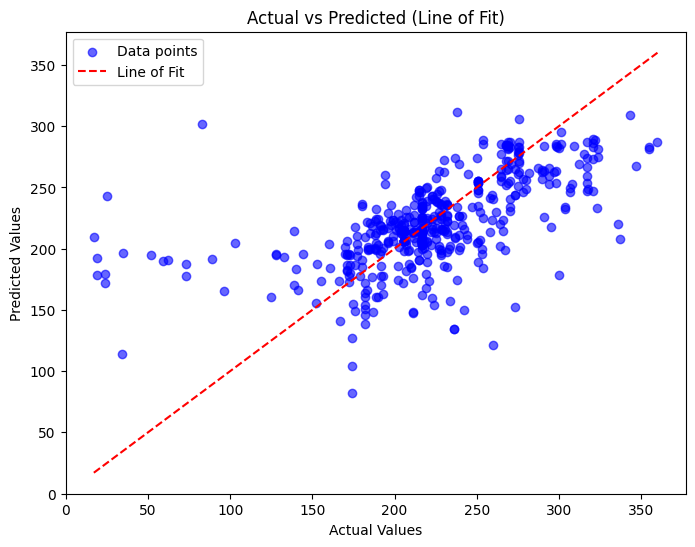

In [1171]:
# Line of Fit Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label='Data points')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Line of Fit')
plt.title('Actual vs Predicted (Line of Fit)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.show()

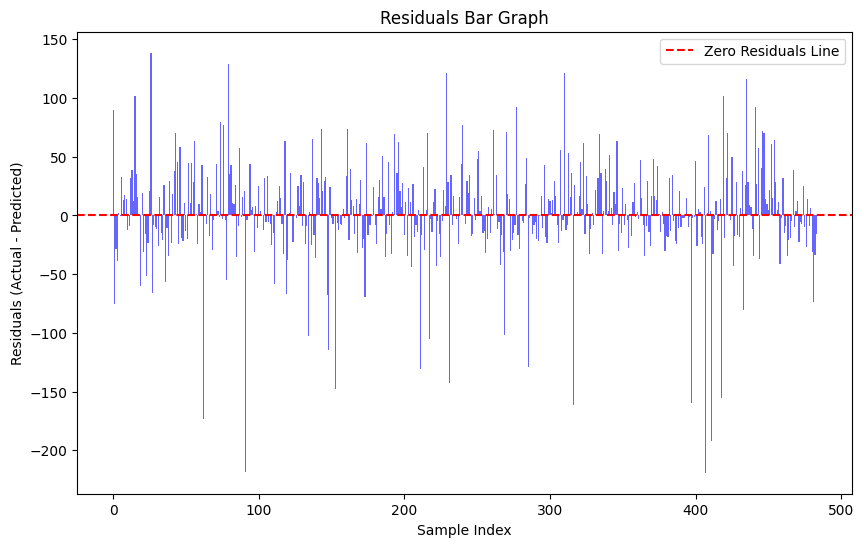

In [1172]:
# Calculate residuals
residuals = y_test - y_pred

# Residuals Plot
plt.figure(figsize=(10, 6))
plt.bar(np.arange(len(residuals)), residuals, color='blue', alpha=0.6)
plt.title('Residuals Bar Graph')
plt.xlabel('Sample Index')
plt.ylabel('Residuals (Actual - Predicted)')
plt.axhline(0, color='red', linestyle='--', label='Zero Residuals Line')
plt.legend()
plt.show()

## Alternative - Random Forest

In [1173]:
# Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [1174]:
# Predict on test set
y_pred_rf = rf_model.predict(X_test)

In [1175]:
# Evaluate performance
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print(f"Mean Absolute Error: {mae_rf}")
print(f"R² Score: {r2_rf}")

Random Forest Performance:
Mean Absolute Error: 14.555110487996854
R² Score: 0.779290223110741


In [1176]:
# Make predictions
rf_results_df = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred_rf})
print(rf_results_df.head(20))

    Actual   Predicted
0      323  302.440000
1      139  173.820000
2      215  215.010000
3      183  227.180000
4      271  271.000000
5      206  206.000000
6      205  178.160000
7      247  232.520000
8      218  215.510000
9      217  217.000000
10     188  224.750000
11     205  208.180000
12     280  293.400000
13     187  203.965833
14     239  233.110000
15     236  194.040000
16     232  226.000000
17     269  328.540000
18     265  288.810000
19     133  177.950000


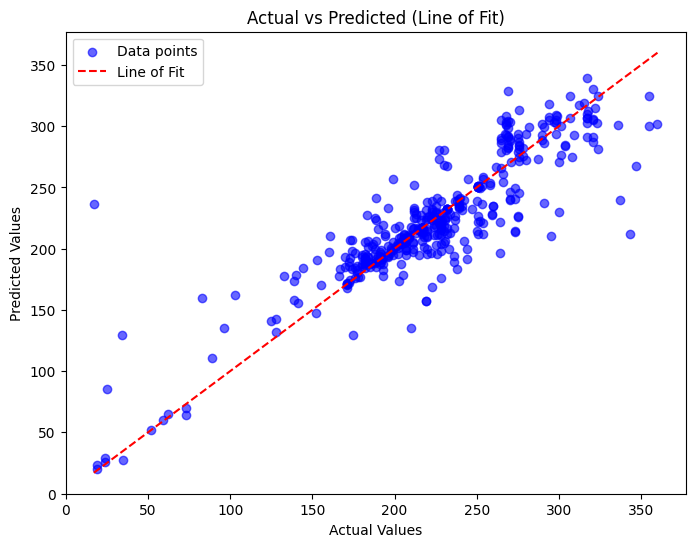

In [1177]:
# Line of Fit Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, color='blue', alpha=0.6, label='Data points')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Line of Fit')
plt.title('Actual vs Predicted (Line of Fit)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.show()

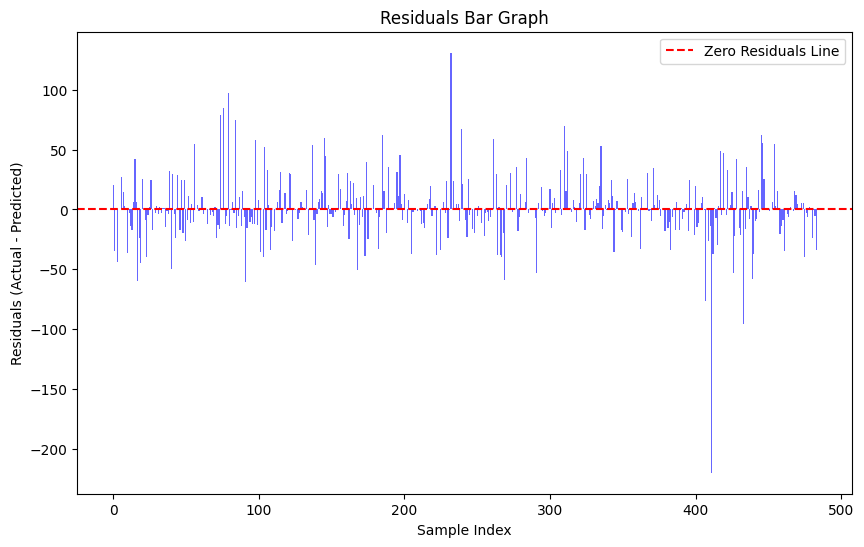

In [1178]:
# Calculate residuals
residuals = y_test - y_pred_rf

# Residuals Plot
plt.figure(figsize=(10, 6))
plt.bar(np.arange(len(residuals)), residuals, color='blue', alpha=0.6)
plt.title('Residuals Bar Graph')
plt.xlabel('Sample Index')
plt.ylabel('Residuals (Actual - Predicted)')
plt.axhline(0, color='red', linestyle='--', label='Zero Residuals Line')
plt.legend()
plt.show()

## Alternative - XGBoost

In [1179]:
# Initialize XGBoost model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Fit the model
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [1180]:
# Predict on test set
y_pred_xgb = xgb_model.predict(X_test)

In [1181]:
# Evaluate performance
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Performance:")
print(f"Mean Absolute Error: {mae_xgb}")
print(f"R² Score: {r2_xgb}")

XGBoost Performance:
Mean Absolute Error: 15.053604330898317
R² Score: 0.7833165725094865


In [1182]:
# Make predictions
rf_results_df = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred_xgb})
print(rf_results_df.head(20))

    Actual   Predicted
0      323  311.403992
1      139  192.827850
2      215  218.018234
3      183  213.666641
4      271  263.394501
5      206  206.769867
6      205  161.068588
7      247  232.388504
8      218  208.629654
9      217  220.973038
10     188  210.733841
11     205  207.029297
12     280  287.889801
13     187  220.826080
14     239  232.635468
15     236  193.760544
16     232  226.056976
17     269  309.093323
18     265  288.031799
19     133  176.000336


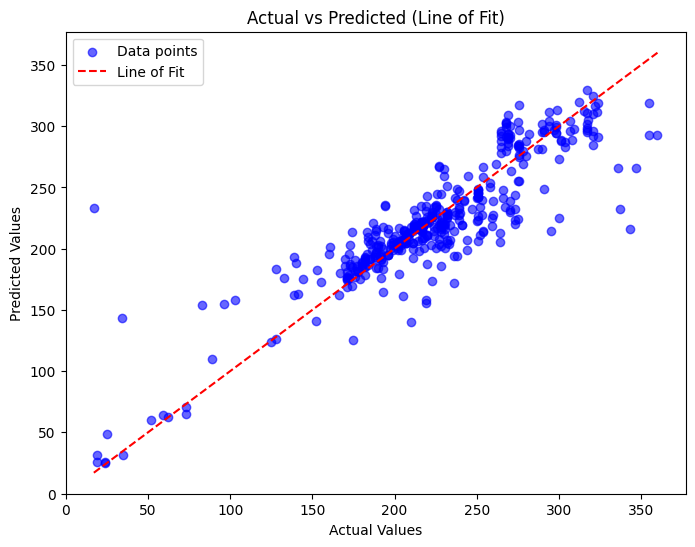

In [1183]:
# Line of Fit Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_xgb, color='blue', alpha=0.6, label='Data points')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Line of Fit')
plt.title('Actual vs Predicted (Line of Fit)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.show()

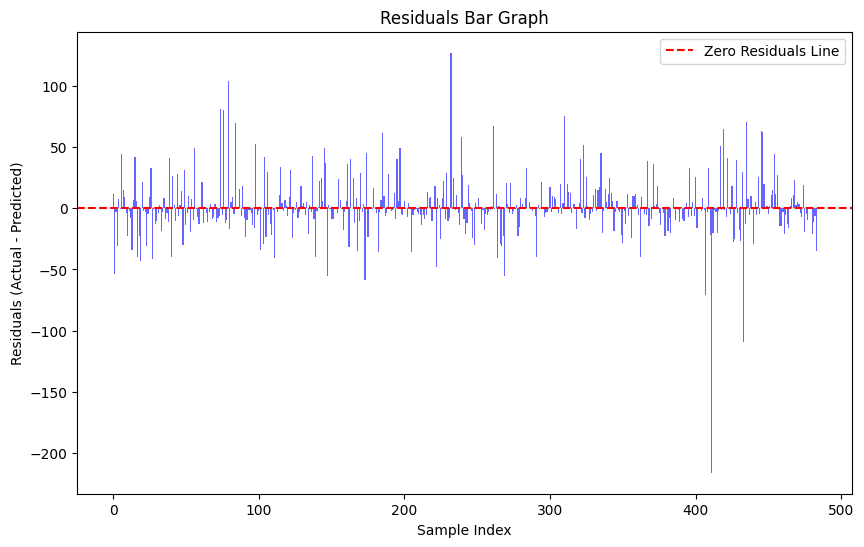

In [1184]:
# Calculate residuals
residuals = y_test - y_pred_xgb

# Residuals Plot
plt.figure(figsize=(10, 6))
plt.bar(np.arange(len(residuals)), residuals, color='blue', alpha=0.6)
plt.title('Residuals Bar Graph')
plt.xlabel('Sample Index')
plt.ylabel('Residuals (Actual - Predicted)')
plt.axhline(0, color='red', linestyle='--', label='Zero Residuals Line')
plt.legend()
plt.show()

## Prediction for 2month and 5month Horizon

### Linear Model

In [1185]:
# Order Date-Based Time Horizon Splits
data_test = data2.loc[X_test.index]
last_date = data_test['Order Date'].max()

In [1186]:
# 5-Month Horizon: Orders from the last 5 months
# 12/31 - 5month = 07/31
# 07/31 - 12/31
horizon_5months = last_date - pd.DateOffset(months=5)
test_5_month = data_test[(data_test['Order Date'] >= horizon_5months)]
X_test_5_month = X_test.loc[test_5_month.index]
y_test_5_month = y_test.loc[test_5_month.index]

In [1187]:
# 2-Month Horizon: Orders from the last 2 months
horizon_2months = last_date - pd.DateOffset(months=2)
test_2_month = data_test[(data_test['Order Date'] >= horizon_2months)]
X_test_2_month = X_test.loc[test_2_month.index]
y_test_2_month = y_test.loc[test_2_month.index]

In [1188]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr_5m = lr_model.predict(X_test_5_month)
y_pred_lr_2m = lr_model.predict(X_test_2_month)

In [1189]:
# 5-month horizon prediction evaluation
mae_lr_5m = mean_absolute_error(y_test_5_month, y_pred_lr_5m)
r2_lr_5m = r2_score(y_test_5_month, y_pred_lr_5m)

print(f"Linear Regression - 5 Month Horizon: MAE = {mae_lr_5m}")
print(f"Linear Regression - 5 Month Horizon: R² = {r2_lr_5m}")

Linear Regression - 5 Month Horizon: MAE = 31.652798704656842
Linear Regression - 5 Month Horizon: R² = 0.09085446687511312


In [1190]:
# 2-month horizon prediction evaluation
mae_lr_2m = mean_absolute_error(y_test_2_month, y_pred_lr_2m)
r2_lr_2m = r2_score(y_test_2_month, y_pred_lr_2m)

print(f"Linear Regression - 2 Month Horizon: MAE = {mae_lr_2m}")
print(f"Linear Regression - 2 Month Horizon: R² = {r2_lr_2m}")

Linear Regression - 2 Month Horizon: MAE = 219.04369401440636
Linear Regression - 2 Month Horizon: R² = nan


/Users/priyachaudhuri/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_regression.py:1187: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


### Random Forest

In [1191]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf_5m = rf_model.predict(X_test_5_month)
y_pred_rf_2m = rf_model.predict(X_test_2_month)

In [1192]:
# 5-month horizon prediction evaluation
mae_rf_5m = mean_absolute_error(y_test_5_month, y_pred_rf_5m)
r2_rf_5m = r2_score(y_test_5_month, y_pred_rf_5m)
                    
print(f"Random Forest - 5 Month Horizon: MAE = {mae_rf_5m}")
print(f"Random Forest - 5 Month Horizon: R² = {r2_rf_5m}")

Random Forest - 5 Month Horizon: MAE = 19.850993533215757
Random Forest - 5 Month Horizon: R² = 0.641609474214476


In [1193]:
# 2-month horizon prediction evaluation
mae_rf_2m = mean_absolute_error(y_test_2_month, y_pred_rf_2m)
r2_rf_2m = r2_score(y_test_2_month, y_pred_rf_2m)

print(f"Random Forest - 2 Month Horizon: MAE = {mae_rf_2m}")
print(f"Random Forest - 2 Month Horizon: R² = {r2_rf_2m}")

Random Forest - 2 Month Horizon: MAE = 76.47
Random Forest - 2 Month Horizon: R² = nan


/Users/priyachaudhuri/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_regression.py:1187: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


### XGBoost

In [1194]:
xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb_5m = xgb.predict(X_test_5_month)
y_pred_xgb_2m = xgb.predict(X_test_2_month)

In [1195]:
# 5-month horizon prediction evaluation
mae_xgb_5m = mean_absolute_error(y_test_5_month, y_pred_xgb_5m)
r2_xgb_5m = r2_score(y_test_5_month, y_pred_xgb_5m)

print(f"XGBoost - 5 Month Horizon: MAE = {mae_xgb_5m}")
print(f"XGBoost - 5 Month Horizon: R² = {r2_xgb_5m}")

XGBoost - 5 Month Horizon: MAE = 17.893131891886394
XGBoost - 5 Month Horizon: R² = 0.6792453033758725


In [1196]:
# 2-month horizon prediction evaluation
mae_xgb_2m = mean_absolute_error(y_test_2_month, y_pred_xgb_2m)
r2_xgb_2m = r2_score(y_test_2_month, y_pred_xgb_2m)

print(f"XGBoost - 2 Month Horizon: MAE = {mae_xgb_2m}")
print(f"XGBoost - 2 Month Horizon: R² = {r2_xgb_2m}")

XGBoost - 2 Month Horizon: MAE = 86.22775268554688
XGBoost - 2 Month Horizon: R² = nan


/Users/priyachaudhuri/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_regression.py:1187: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


# Monte Carlo

In [1197]:
y_pred_2.size, y_pred_5.size, y_pred_2items.size, y_pred_5items.size, y_pred_lr_2m.size, y_pred_lr_5m.size

(1, 81, 1, 81, 1, 81)

In [1198]:
monte_carlo_df_2m = pd.DataFrame({'demand_class_2m': y_pred_2,
                               'items_2m': y_pred_2items,
                               'lead_time_2m': y_pred_lr_2m
})


monte_carlo_df_5m = pd.DataFrame({'demand_class_5m': y_pred_5,
                               'items_5m': y_pred_5items,
                               'lead_time_5m': y_pred_lr_5m
})


In [1199]:
forecast_2_values, forecast_5_values

(2012-12-01     33.395312
 2013-01-01    119.197485
 Freq: MS, Name: predicted_mean, dtype: float64,
 2012-12-01     33.395312
 2013-01-01    119.197485
 2013-02-01     51.499147
 2013-03-01     28.631145
 2013-04-01      6.763144
 Freq: MS, Name: predicted_mean, dtype: float64)

In [1200]:
monte_carlo_df_2m.describe()

,demand_class_2m,items_2m,lead_time_2m
count,1.0,1.00,1.000000
mean,1.0,7.39,302.043694
std,NaN,NaN,NaN
min,1.0,7.39,302.043694
25%,1.0,7.39,302.043694
50%,1.0,7.39,302.043694
75%,1.0,7.39,302.043694
max,1.0,7.39,302.043694


In [1201]:
monte_carlo_df_5m.describe()

,demand_class_5m,items_5m,lead_time_5m
count,81.000000,81.000000,81.000000
mean,2.604938,5.116127,201.229076
std,0.903867,4.240944,28.904879
min,1.000000,0.270000,114.329576
25%,2.000000,3.209444,182.634291
50%,2.000000,4.380000,200.172247
75%,3.000000,5.846071,219.582738
max,4.000000,36.380000,302.043694


In [1221]:
# Updated parameters based on provided data
mean_demand_class_2m, std_demand_class_2m = 1.0, 0.0  # Single value
mean_items_2m, std_items_2m = 7.39, 0.0
mean_lead_time_2m, std_lead_time_2m = 302.04, 0.0

mean_demand_class_5m, std_demand_class_5m = 2.60, 0.90
mean_items_5m, std_items_5m = 5.12, 4.24
mean_lead_time_5m, std_lead_time_5m = 201.23, 28.90

lead_time_threshold_2m = mean_lead_time_2m
lead_time_threshold_5m = mean_lead_time_5m
# Validate Monte Carlo data for zero std
if std_demand_class_2m == 0.0:
    monte_carlo_df_2m["demand_class_2m"] = [mean_demand_class_2m] * 1
if std_items_2m == 0.0:
    monte_carlo_df_2m["items_2m"] = [mean_items_2m] * 1
if std_lead_time_2m == 0.0:
    monte_carlo_df_2m["lead_time_2m"] = [mean_lead_time_2m] * 1

# Validate forecast data
forecast_2 = pd.Series(forecast_2_values, index=pd.date_range("2012-01-01", periods=2, freq="MS")).fillna(0)
forecast_5 = pd.Series(forecast_5_values, index=pd.date_range("2012-01-01", periods=5, freq="MS")).fillna(0)

# Monte Carlo simulation function
def monte_carlo_simulation_from_data(forecast, mc_data, horizon, simulations=1000):
    simulated_data = []
    for i in range(simulations):
        simulation = []
        for t in range(horizon):
            # Sample from Monte Carlo data
            demand_class = np.random.choice(mc_data[f"demand_class_{horizon}m"], size=1)
            items = np.random.choice(mc_data[f"items_{horizon}m"], size=1)
            lead_time = np.random.choice(mc_data[f"lead_time_{horizon}m"], size=1)

            # Validate forecast and items
            if pd.isna(forecast.iloc[t]) or items[0] <= 0:
                continue

            # Calculate total demand
            total_demand = forecast.iloc[t] * items
            simulation.append({
                "time": forecast.index[t],
                "demand_class": demand_class[0],
                "items": items[0],
                "lead_time": lead_time[0],
                "total_demand": total_demand[0],
            })

        simulated_data.extend(simulation)
    return pd.DataFrame(simulated_data)

# Simulate 2-month and 5-month horizons
simulated_2m = monte_carlo_simulation_from_data(forecast_2, monte_carlo_df_2m, horizon=2)
simulated_5m = monte_carlo_simulation_from_data(forecast_5, monte_carlo_df_5m, horizon=5)

# Classify advance and urgent demand
def classify_demand(data, lead_time_threshold):
    data["demand_type"] = data["lead_time"].apply(lambda x: "Advance" if x > lead_time_threshold else "Urgent")
    return data
# Classify demand
simulated_2m = classify_demand(simulated_2m, lead_time_threshold=lead_time_threshold_2m)
simulated_5m = classify_demand(simulated_5m, lead_time_threshold=lead_time_threshold_5m)

# Group simulated data
simulated_2m_grouped = simulated_2m[simulated_2m["demand_type"] == "Advance"].groupby("time")["total_demand"].mean().reindex(forecast_2.index, fill_value=0)
simulated_5m_grouped = simulated_5m[simulated_5m["demand_type"] == "Advance"].groupby("time")["total_demand"].mean().reindex(forecast_5.index, fill_value=0)

# Define metrics
def calculate_metrics(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    return mae, mse, rmse
# Evaluate metrics
mae_2m, mse_2m, rmse_2m = calculate_metrics(forecast_2.values, simulated_2m_grouped.values)
mae_5m, mse_5m, rmse_5m = calculate_metrics(forecast_5.values, simulated_5m_grouped.values)

# Display results
print("2-Month Horizon Metrics:")
print(f"MAE: {mae_2m}, MSE: {mse_2m}, RMSE: {rmse_2m}")

print("\n5-Month Horizon Metrics:")
print(f"MAE: {mae_5m}, MSE: {mse_5m}, RMSE: {rmse_5m}")



2-Month Horizon Metrics:
MAE: 0.0, MSE: 0.0, RMSE: 0.0

5-Month Horizon Metrics:
MAE: 0.0, MSE: 0.0, RMSE: 0.0


# Summary Report:


How many distinct orders are received in each month?
The dataset reveals a monthly trend in order placements. The number of distinct orders received fluctuates throughout the year, with some months experiencing significantly higher order volumes than others. For example:

In July 2011, a peak of 238 distinct orders was recorded, showcasing a high demand period.
Other months like March 2010 had moderate order counts (43 orders), while months such as May 2010 and April 2012 only recorded a single order. This trend suggests seasonality or specific events driving demand in certain months. Understanding these patterns can help in forecasting and resource allocation.
Which items are demanded?
Among the items in the dataset, the "Parka Outdoor Lifestyle STD" is the most highly demanded product, making up a significant proportion of the orders. This item might reflect its popularity due to specific market needs or its suitability for the target audience. Other items in the dataset may have been demanded as well, but their frequency is notably lower compared to the leading product. This highlights the need to prioritize inventory management for the most popular items.

What is the quantity demanded for each item in these orders?
The quantity demanded varies widely across different items. For the "Parka Outdoor Lifestyle STD," a substantial total quantity has been ordered, indicating its importance in the product portfolio. Other products, while demanded, may exhibit much smaller order quantities. This variation in demand volume can inform procurement, production planning, and marketing strategies to ensure that supply aligns with customer needs.

What is the demand lead time for these orders (time elapsed from order receipt to delivery)?
On average, the demand lead time is approximately 221.24 days, highlighting a relatively long fulfillment cycle. This extended lead time could be due to factors such as production schedules, supplier delays, or logistical challenges. Reducing this lead time would enhance customer satisfaction and improve operational efficiency. Additionally, understanding this lead time is crucial for accurate delivery promises and inventory management.

Insights and Recommendations:
Demand Forecasting: The observed monthly order trends indicate that certain months experience a spike in demand. Businesses should focus on increasing production and inventory during peak months to meet customer requirements efficiently.
Product Prioritization: Given the dominance of specific products like the "Parka Outdoor Lifestyle STD," it would be wise to allocate resources and marketing efforts to these high-demand items while exploring ways to boost sales of less popular products.
Supply Chain Optimization: The long lead time presents an opportunity for improvement. Streamlining the supply chain and exploring alternative suppliers or logistical partners could significantly reduce delays and improve delivery timelines.
Strategic Planning: Businesses should leverage this data to align their operations, marketing, and inventory strategies with the observed demand patterns, ensuring that customer needs are met effectively.
